# Introduction

Fig 4B-C: New clonotype expansion in CD8T cells

In [1]:
fig.size <- function(h, w) {
    options(repr.plot.height = h, repr.plot.width = w)
}

In [2]:
library(data.table)
library(dplyr)
library(tidyr)
library(ggplot2)
library(furrr)
library(ggrepel)
library(ggthemes)
library(ggpubr)
library(patchwork)

Warning message:
“package ‘dplyr’ was built under R version 4.1.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘tidyr’ was built under R version 4.1.3”
Loading required package: future



In [ ]:
fdir <- "tcr/"
cells = fread(file.path(fdir,'cd8_tcr.csv'))
cells = cells[, .(patientID, cdr3_beta, treatment, response)]

In [5]:
all_cells = fread(file.path(fdir, 'allcd8_tcr.csv'))
all_cells = all_cells[, .(patientID, cdr3_beta, treatment, response, transferCd8tCellType)]
act_lvls = c(4,7,8)
all_cells <- all_cells %>% 
    mutate(type = if_else(transferCd8tCellType %in% act_lvls, "act", "non_act"))

In [6]:
nonact_cell <- all_cells %>% 
    filter(type == "non_act")

# Act CD8T

## Overview

In [8]:
cells %>% head()

patientID,cdr3_beta,treatment,response
<chr>,<chr>,<chr>,<chr>
P02,CASSEQDPKIRTTQYF,On,R
P02,CAIRDSGGEQETQYF,On,R
P02,CAIRDSGGEQETQYF,On,R
P02,CAIRDSGGEQETQYF,On,R
P02,CAIRDSGGEQETQYF,On,R
P02,CASSLPQETQYF,On,R


### Pre to On

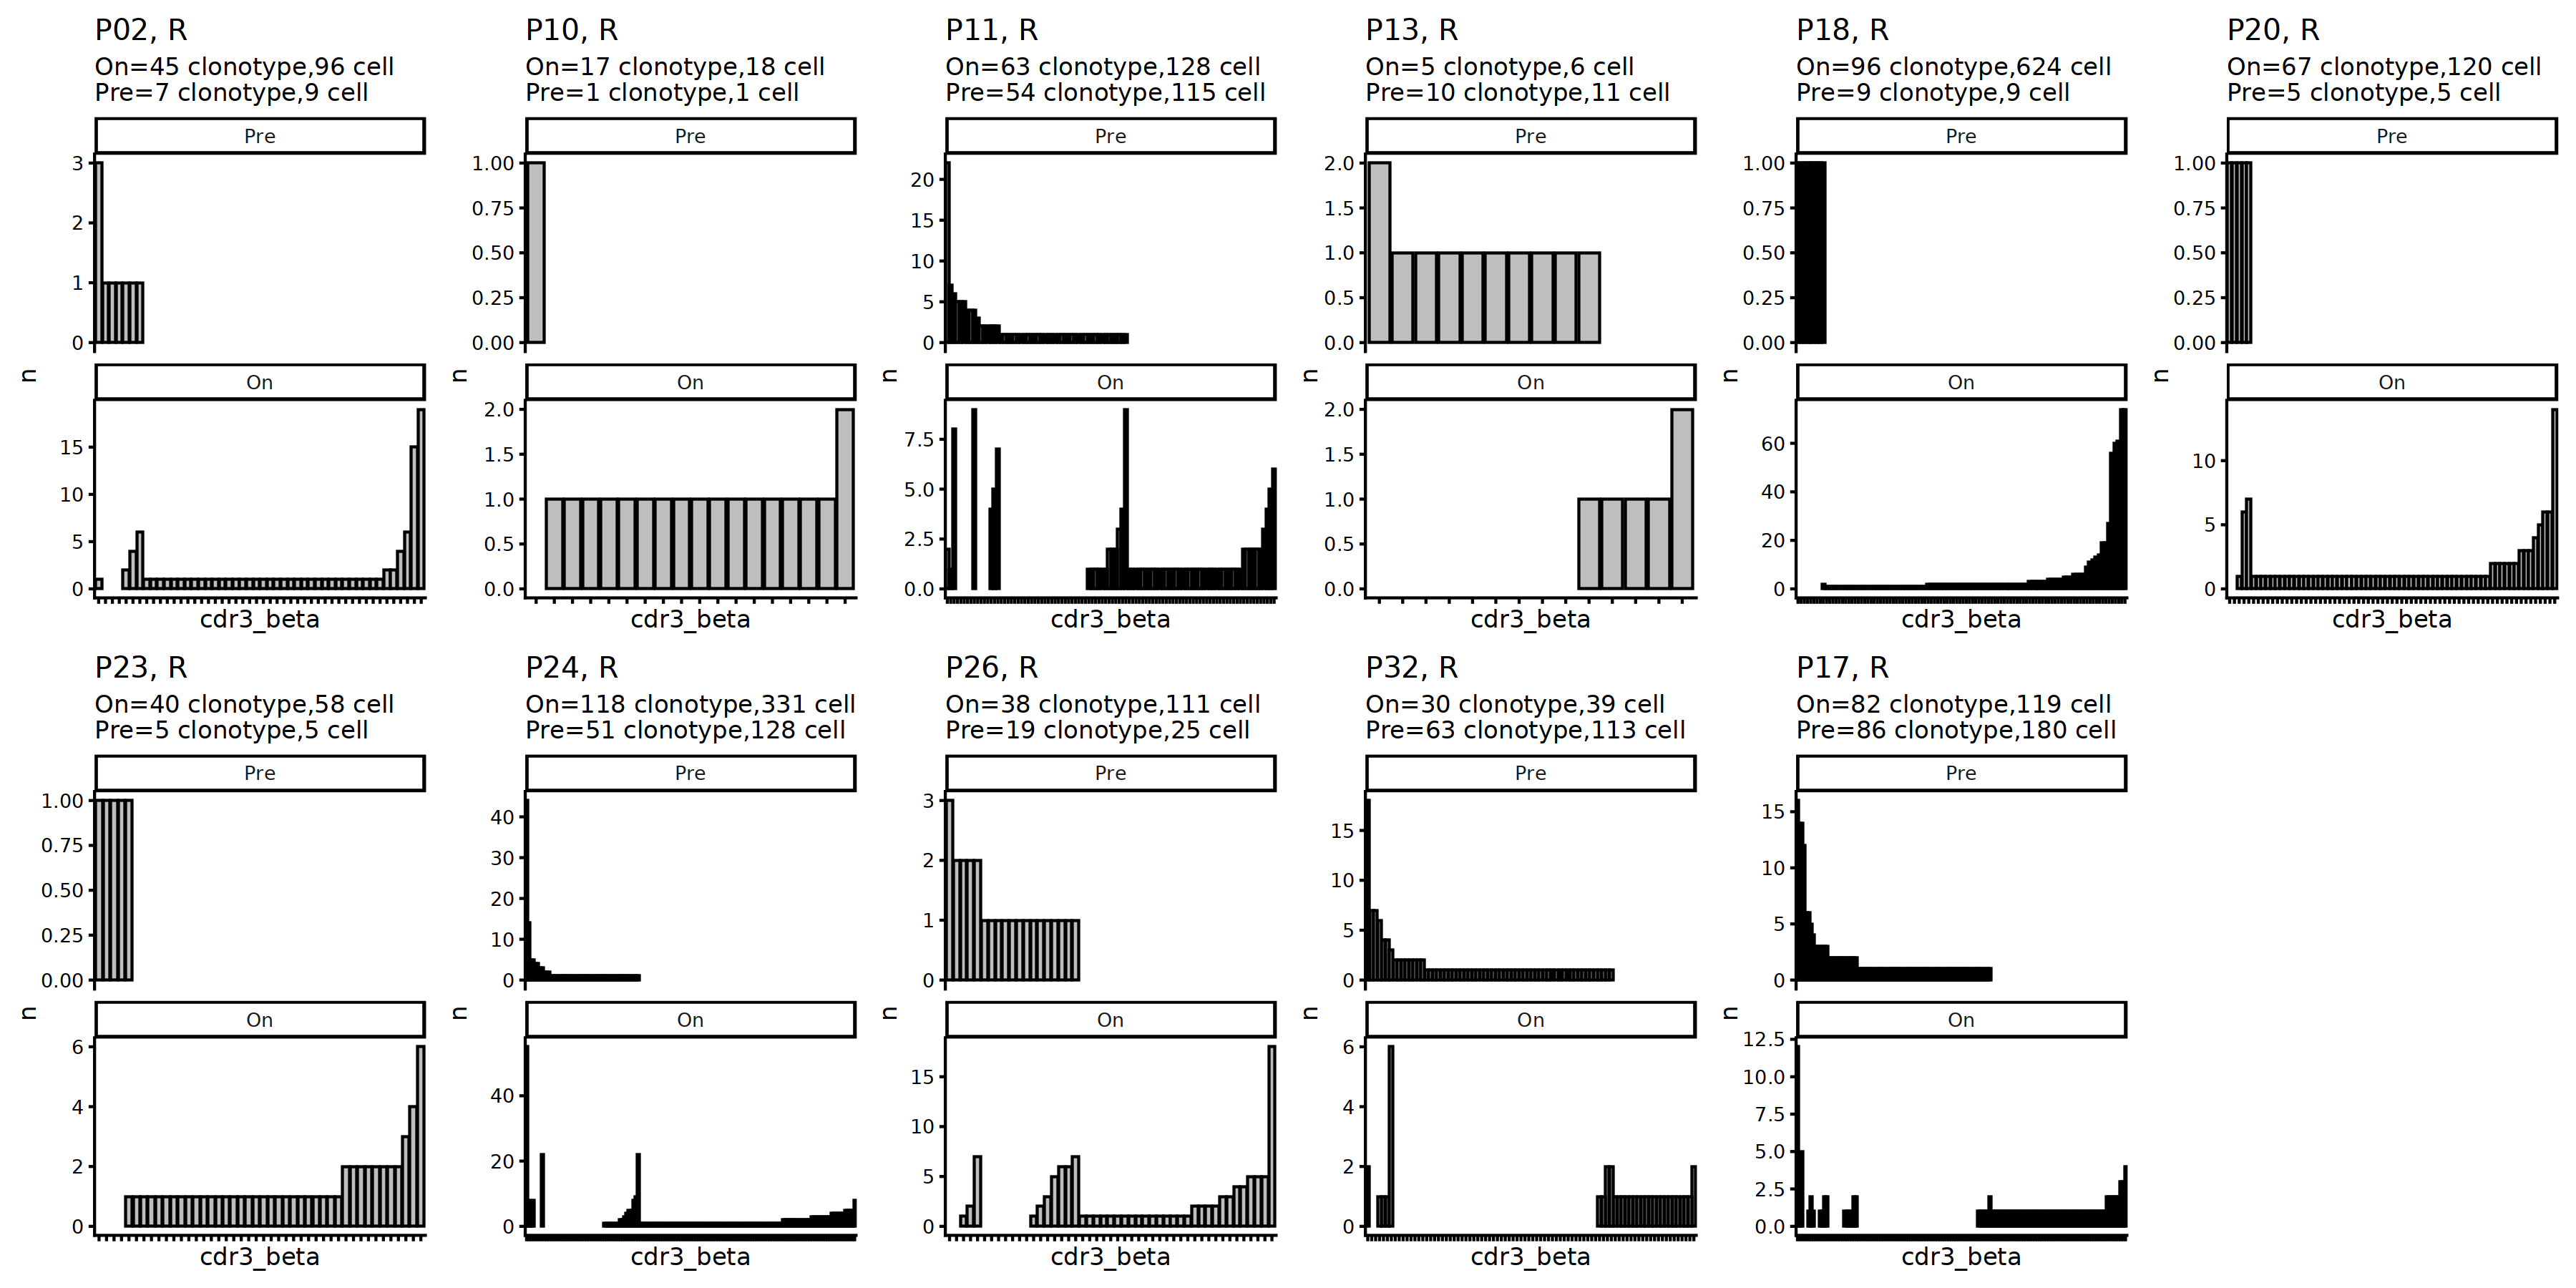

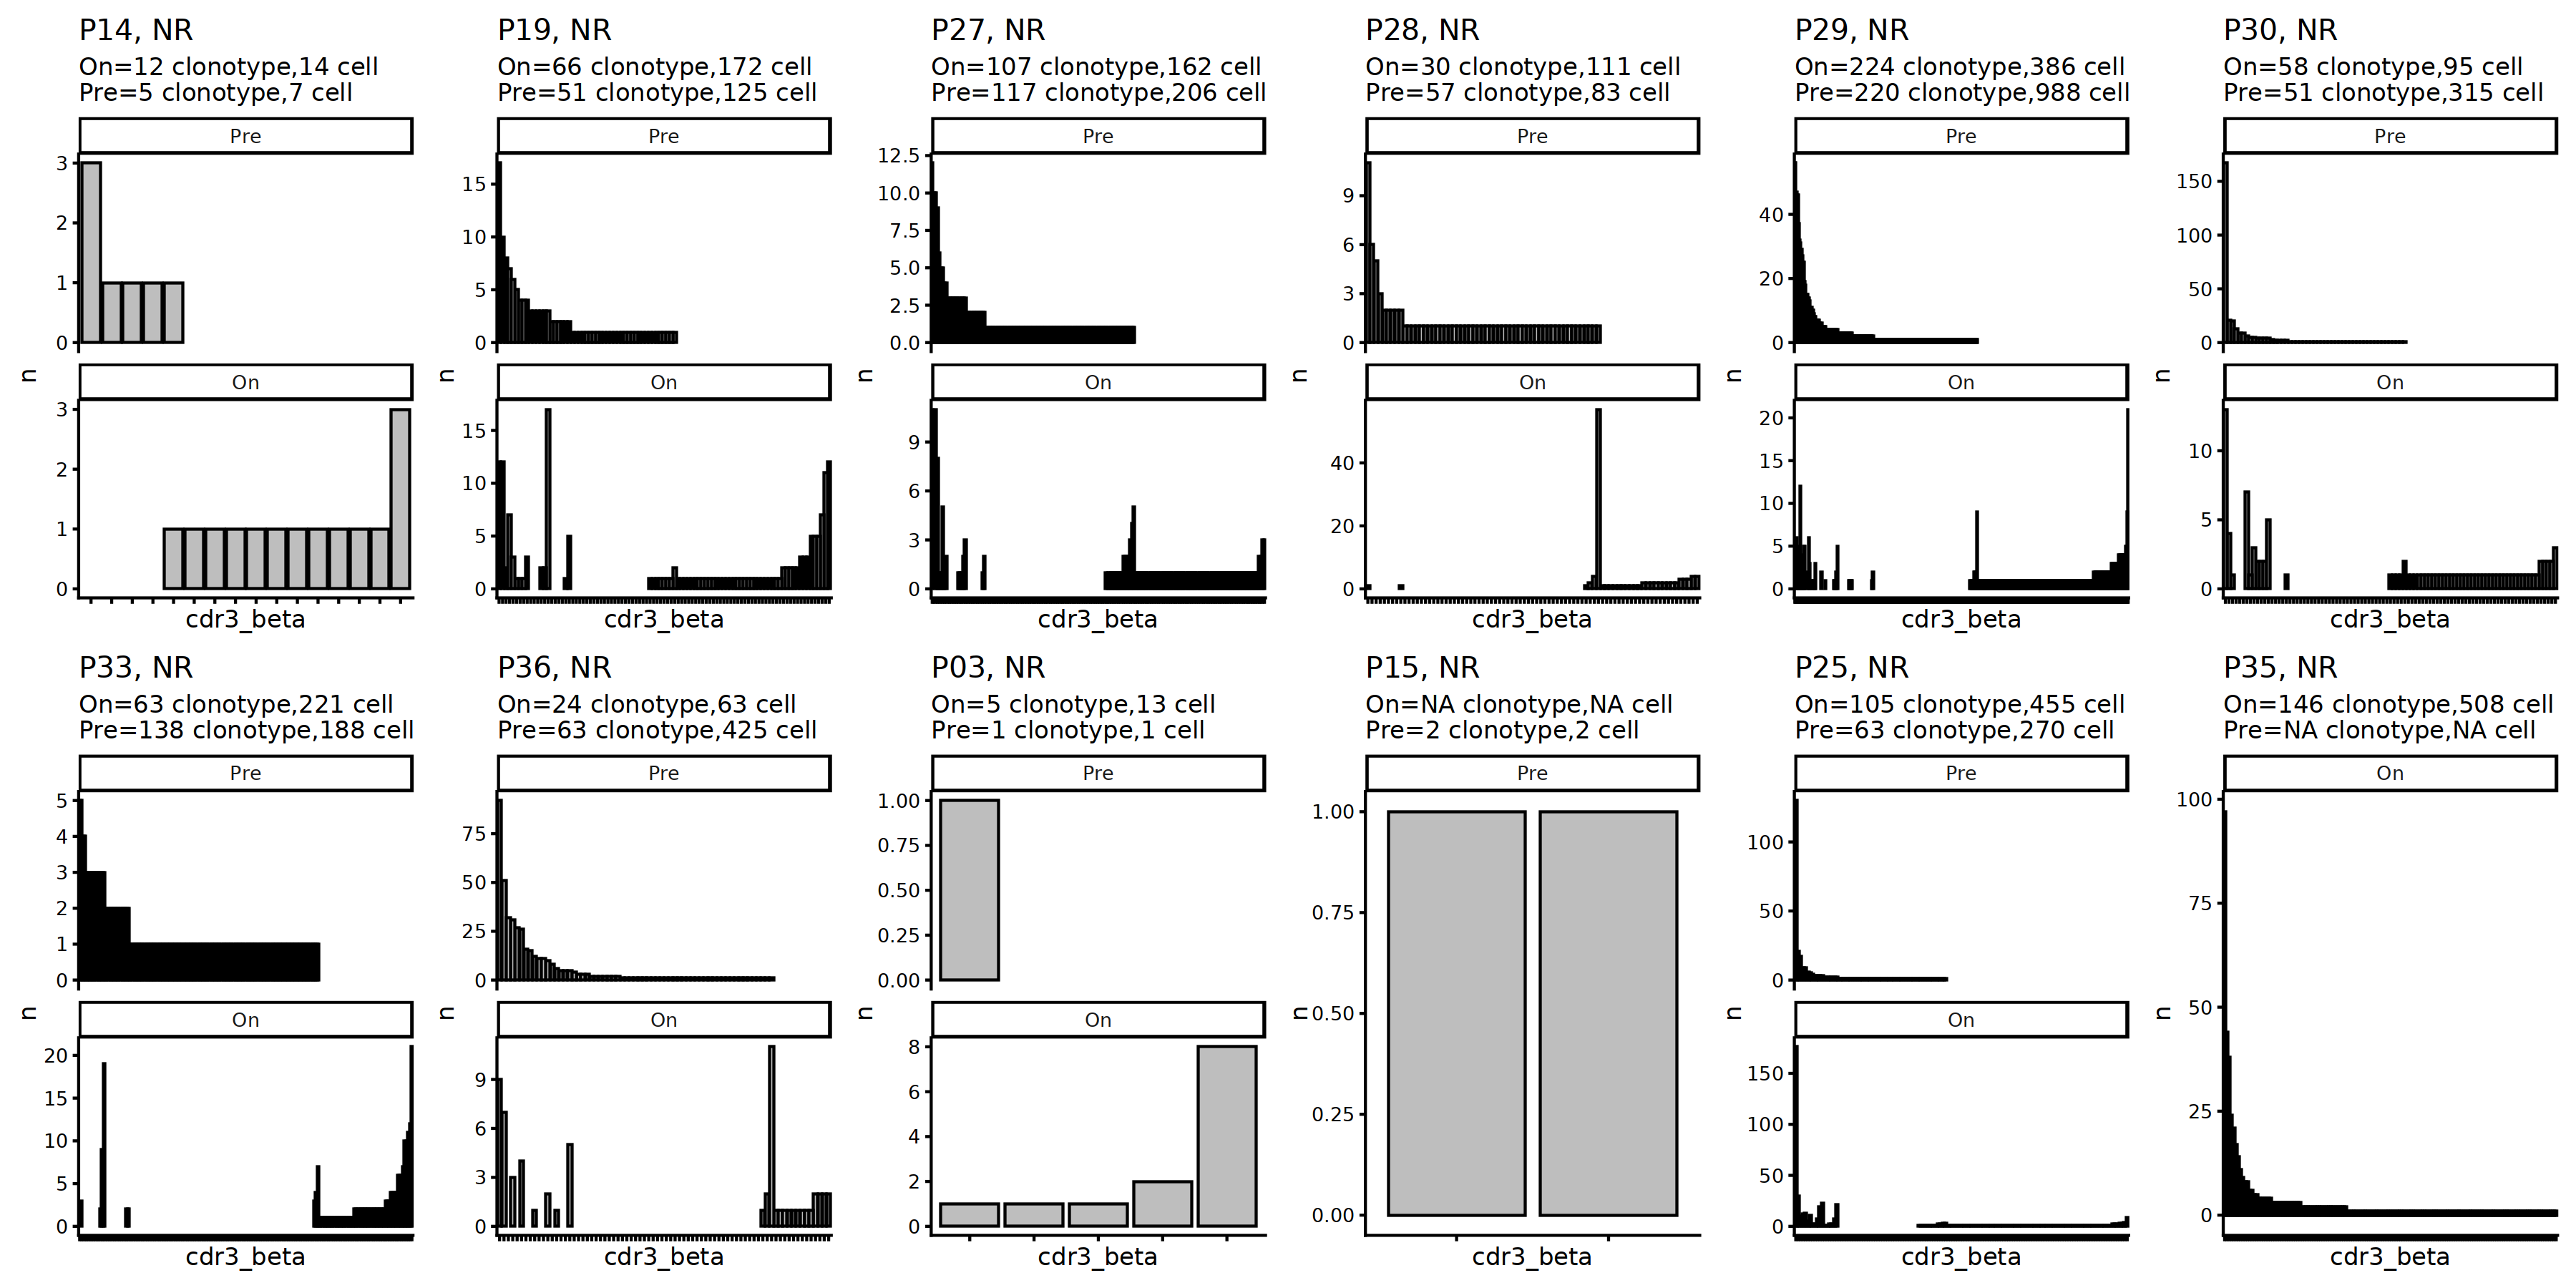

In [9]:
patientID_list <- cells %>% 
    dplyr::distinct(patientID, response) %>% 
    split(.$response) %>% 
    purrr::map(function(.df).df$patientID)

plist <- cells %>% 
    count(patientID, treatment, response, cdr3_beta) %>% 
    split(.$patientID) %>% 
    purrr::map(function(.df){
        if(length(unique(.df$treatment)) == 1) {
            cdr3_beta_lvl <- .df %>% arrange(desc(n)) %>% pull(cdr3_beta) 
        } else{
            cdr3_beta_lvl <- .df %>% 
                pivot_wider(names_from = "treatment", values_from = n, values_fill = 0) %>% 
                arrange(desc(Pre), On) %>% 
                pull(cdr3_beta)}
        
        patientID <- .df[1, "patientID"]
        response <- .df[1, "response"]
        num_df <- .df %>% 
            group_by(treatment) %>% 
            summarise(n_clonotype = n(), n_cell=sum(n)) %>%
            tibble::column_to_rownames("treatment")
        p <- .df %>% 
            mutate(cdr3_beta = factor(cdr3_beta, levels = cdr3_beta_lvl)) %>% 
            mutate(treatment = factor(treatment, levels=c("Pre", "On"))) %>% 
            ggplot(aes(x = cdr3_beta, y = n)) +
                geom_bar(stat = "identity", color = "black", fill = "gray") +
                facet_wrap(~ treatment, ncol=1, scales = "free_y") +
                theme_classic(base_size = 20) +
                theme(axis.text.x = element_blank()) +
                labs(title=paste0(patientID, ", ", response), subtitle=paste0(
                    "On=", num_df["On", "n_clonotype"], " clonotype", ",", 
                    num_df["On", "n_cell"], " cell", "\n",
                    "Pre=", num_df["Pre", "n_clonotype"], " clonotype", ",",
                    num_df["Pre", "n_cell"], " cell")) +
                NULL
    })

fig.size(15, 30)
plist[patientID_list$R] %>% 
    wrap_plots(ncol = 6)
plist[patientID_list$NR] %>% 
    wrap_plots(ncol = 6)

### On to Pre

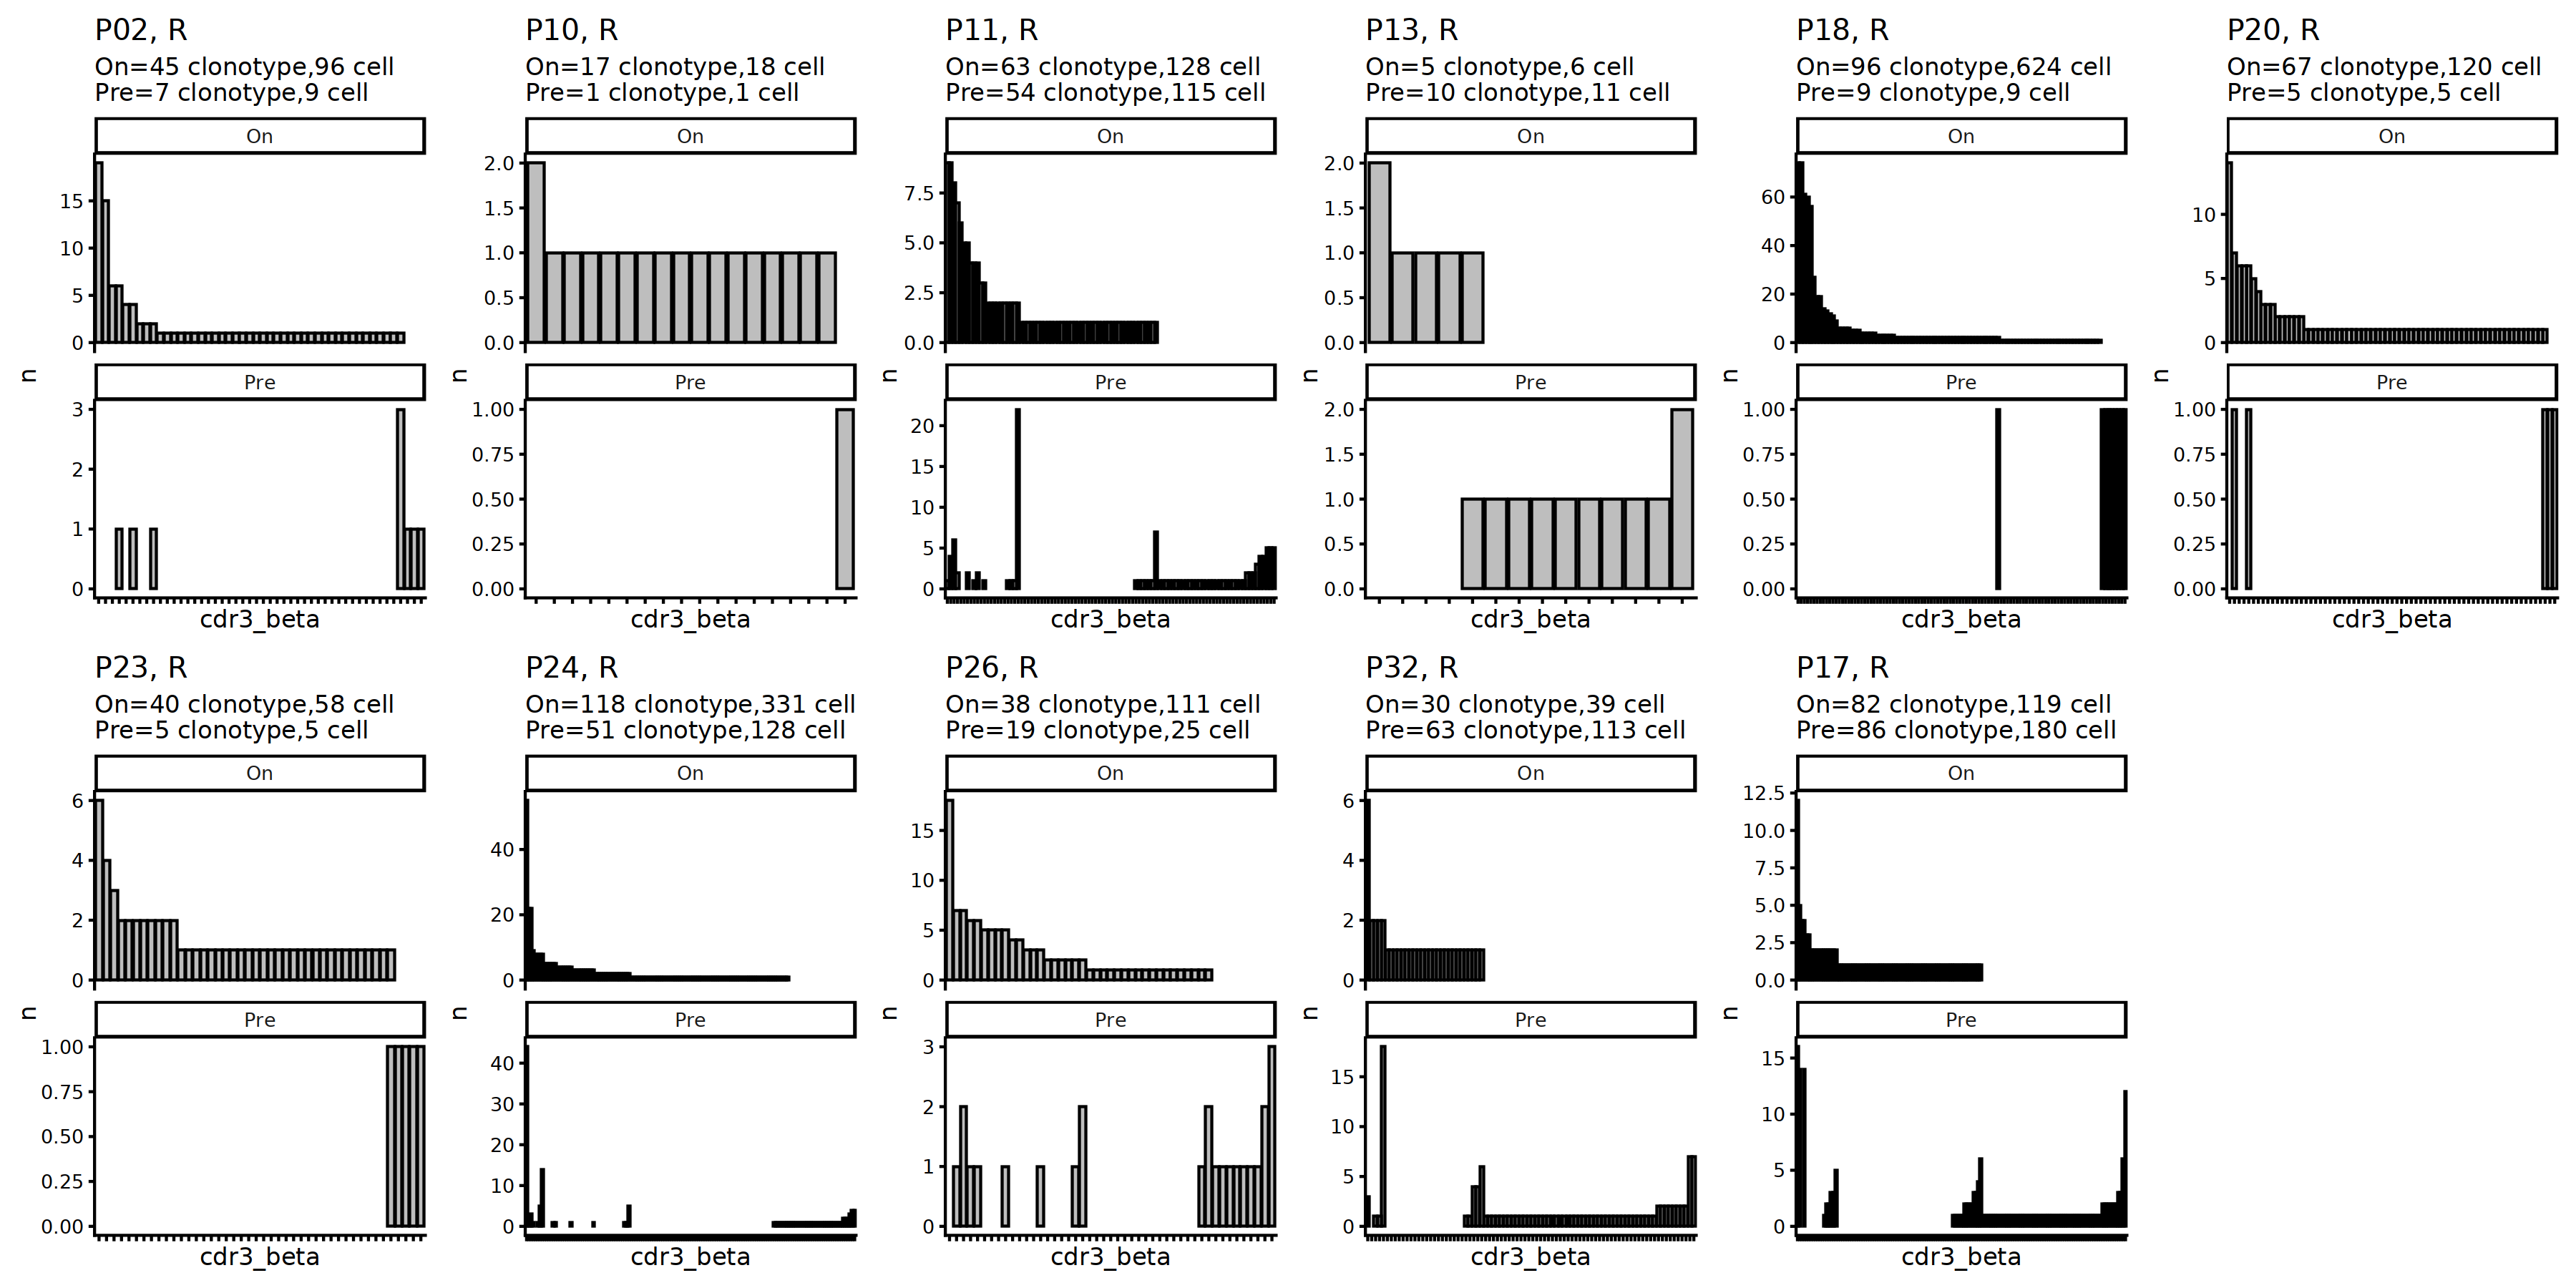

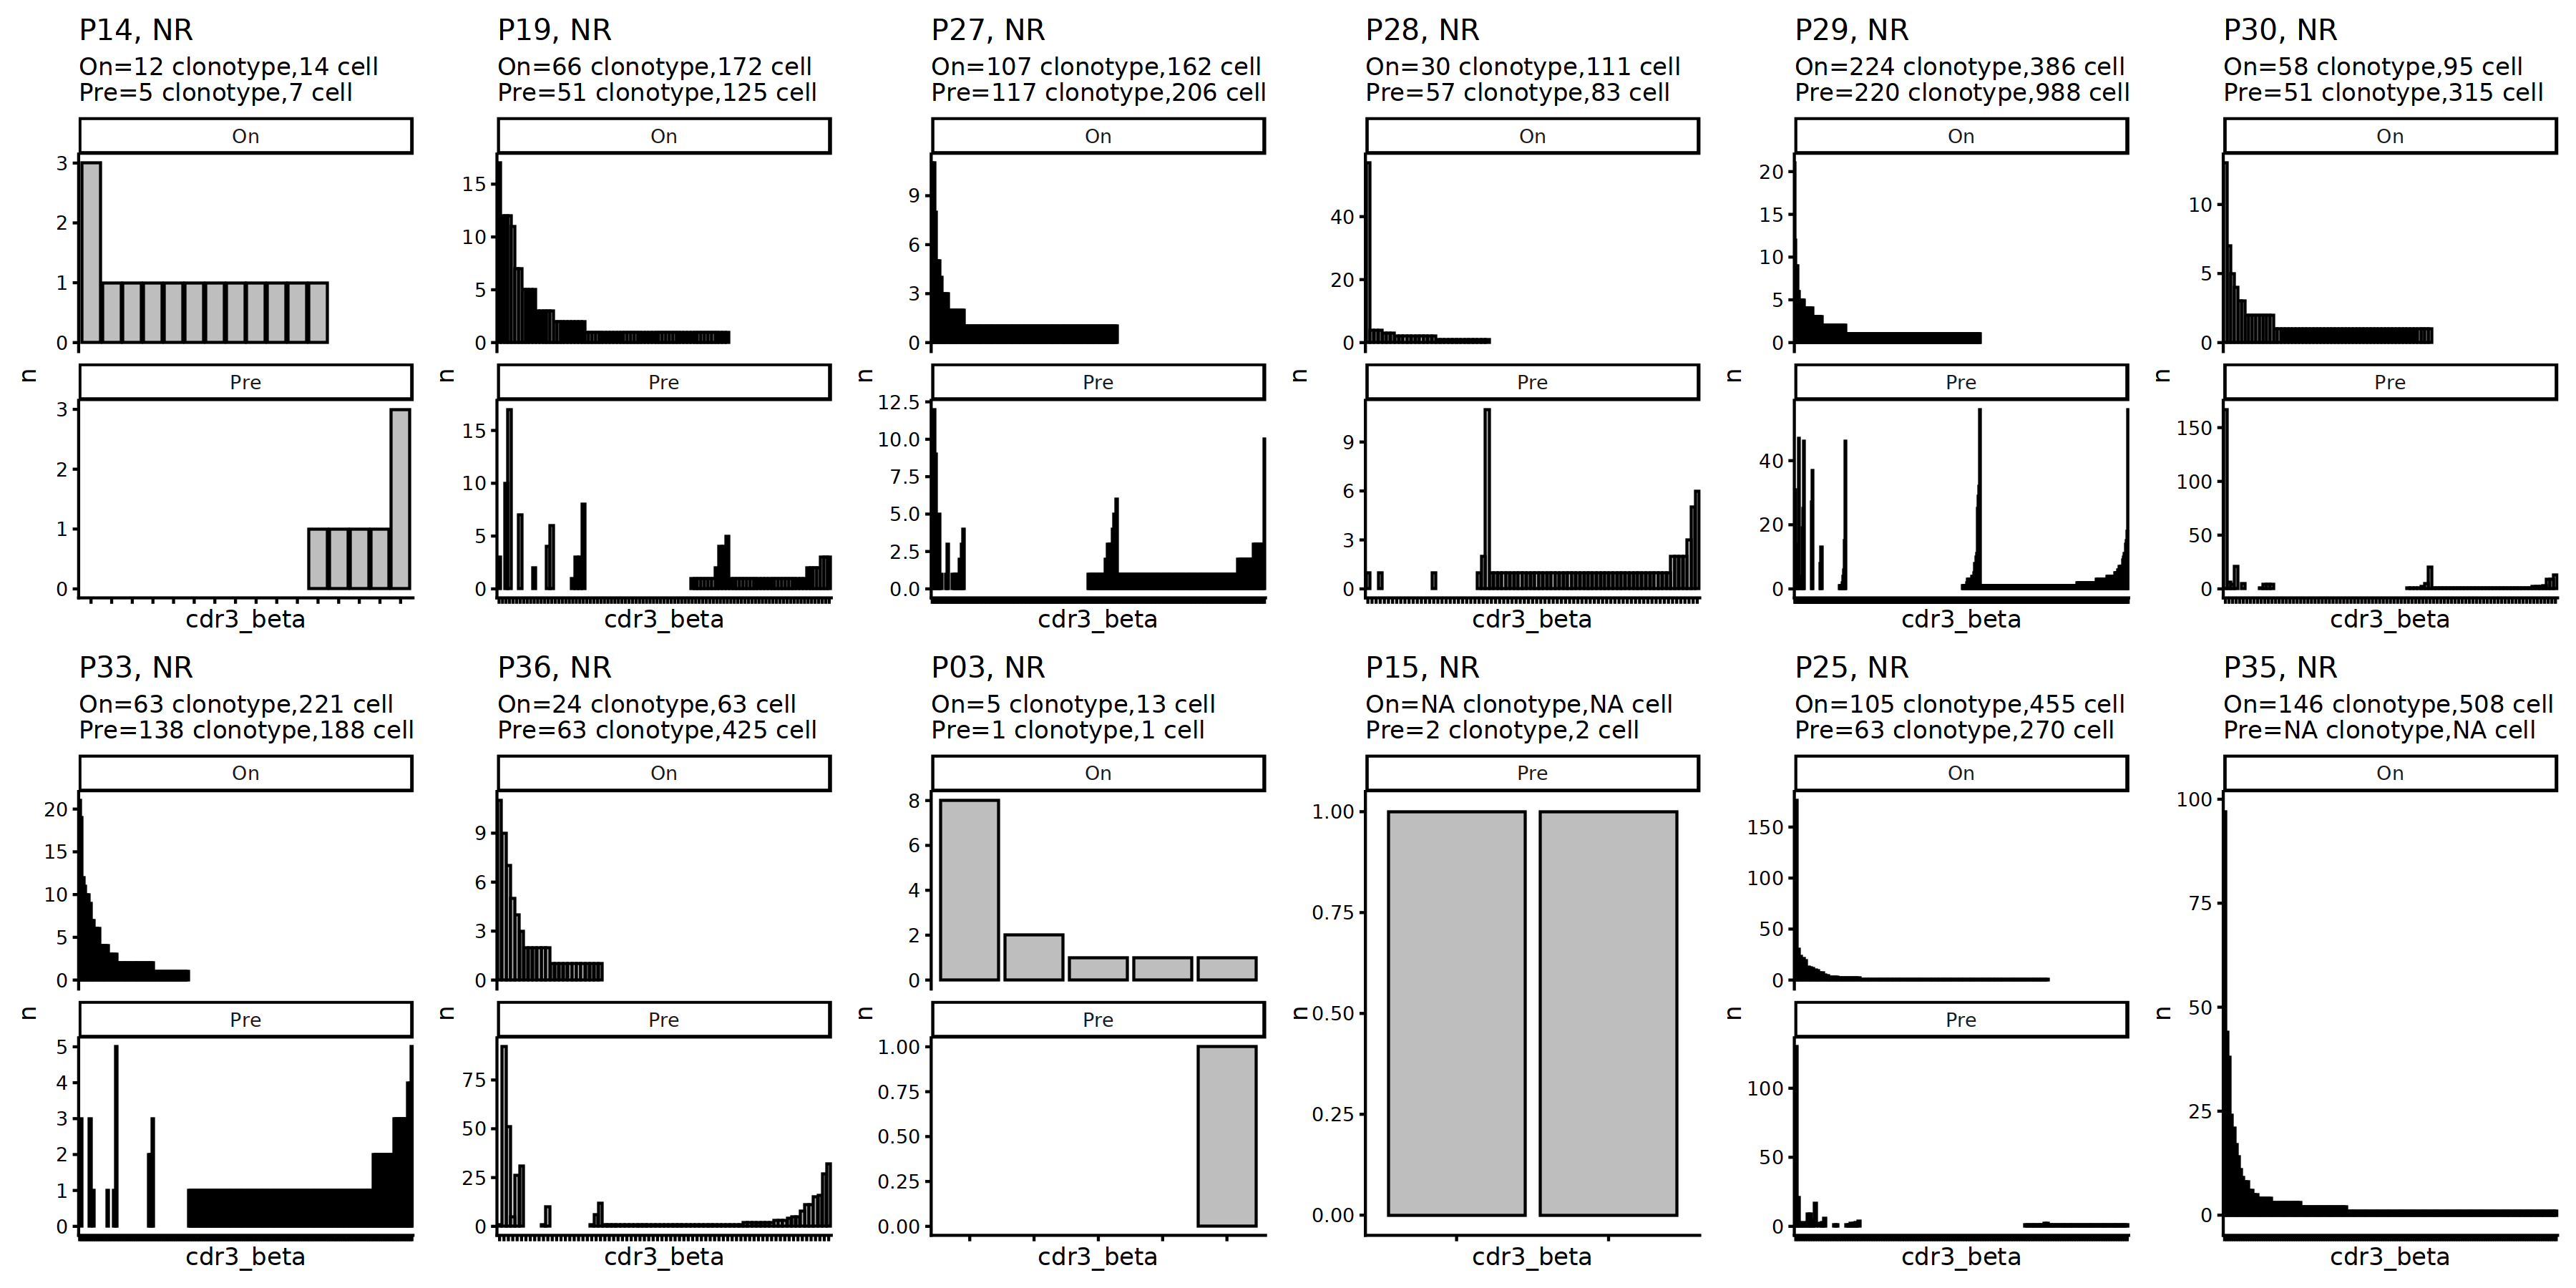

In [10]:
patientID_list <- cells %>% 
    dplyr::distinct(patientID, response) %>% 
    split(.$response) %>% 
    purrr::map(function(.df).df$patientID)

plist <- cells %>% 
    count(patientID, treatment, response, cdr3_beta) %>% 
    split(.$patientID) %>% 
    purrr::map(function(.df){
        if(length(unique(.df$treatment)) == 1) {
            cdr3_beta_lvl <- .df %>% 
                arrange(desc(n)) %>% 
                pull(cdr3_beta) 
        } else{
            cdr3_beta_lvl <- .df %>% 
                pivot_wider(names_from = "treatment", values_from = n, values_fill = 0) %>% 
                arrange(desc(On), Pre) %>% 
                pull(cdr3_beta) 
            
        }
        patientID <- .df[1, "patientID"]
        response <- .df[1, "response"]
        num_df <- .df %>% 
            group_by(treatment) %>% 
            summarise(n_clonotype = n(), n_cell=sum(n)) %>%
            tibble::column_to_rownames("treatment")
        .df %>% 
            mutate(cdr3_beta = factor(cdr3_beta, levels = cdr3_beta_lvl)) %>% 
            mutate(treatment = factor(treatment, levels=c("On", "Pre"))) %>% 
            ggplot(aes(x = cdr3_beta, y = n)) +
                geom_bar(stat = "identity", color = "black", fill = "gray") +
                facet_wrap(~ treatment, ncol=1, scales = "free_y") +
                theme_classic(base_size = 20) +
                theme(axis.text.x = element_blank()) +
                labs(title=paste0(patientID, ", ", response), subtitle=paste0(
                    "On=", num_df["On", "n_clonotype"], " clonotype", ",", 
                    num_df["On", "n_cell"], " cell", "\n",
                    "Pre=", num_df["Pre", "n_clonotype"], " clonotype", ",",
                    num_df["Pre", "n_cell"], " cell")) +
                NULL
    })

fig.size(15, 30)
plist[patientID_list$R] %>% 
    wrap_plots(ncol = 6)
plist[patientID_list$NR] %>% 
    wrap_plots(ncol = 6)

### Num of cells per sample

In [11]:
cells %>% 
    count(patientID, treatment) %>% 
    pivot_wider(values_from = "n", names_from = "treatment", values_fill=0)

cells %>% 
    unique() %>% 
    count(patientID, treatment) %>% 
    pivot_wider(values_from = "n", names_from = "treatment", values_fill=0)

patientID,On,Pre
<chr>,<int>,<int>
P02,96,9
P03,13,1
P10,18,1
P11,128,115
P13,6,11
P14,14,7
P15,0,2
P17,119,180
P18,624,9


patientID,On,Pre
<chr>,<int>,<int>
P02,45,7
P03,5,1
P10,17,1
P11,63,54
P13,5,10
P14,12,5
P15,0,2
P17,82,86
P18,96,9


## Test num of cell

In [12]:
## Function to do one test 
permute_cell = function(ids, grp, lvl, Bperm = 20000) {
    if (length(unique(grp)) < 2) return(NULL)
    lvlB = lvl ## the group we care about
    lvlA = setdiff(unique(grp), lvl) ## the background group
    
    nA = sum(grp == lvlA)
    nB = sum(grp == lvlB)
    
    # Build 2xK counts once
    tab0 <- table(grp, ids)
    a <- as.numeric(tab0[lvlA, ])
    b <- as.numeric(tab0[lvlB, ])
    S_obs <- sum(b[(a == 0) & (b > 0)]) 
    
    # Permutation null
    S_perm <- numeric(Bperm)
    for (t in 1:Bperm) {
      grp_perm <- sample(grp, length(grp), replace = FALSE)
      tab <- table(grp_perm, ids)
      a <- as.numeric(tab[lvlA, ]); b <- as.numeric(tab[lvlB, ])
      S_perm[t] <- sum(b[(a == 0) & (b > 0)]) 
      # Or the capped/weighted version to match your choice
    }
    p_larger <- mean(S_perm >= S_obs)
    # p_one_sided <- mean(S_perm >= S_obs)
    p_smaller <- mean(S_perm <= S_obs)
    
    data.table(S_obs = S_obs, p_larger = p_larger, p_smaller=p_smaller,
         expected_S = mean(S_perm), sd_S = sd(S_perm))
}

## Loop over patients, attach metadata to results, and get FDR
permute_cell_all = function(cells, lvl) {
    res = cells %>% 
        split(.$patientID) %>% 
        future_map(function(.SD) permute_cell(.SD$cdr3_beta, .SD$treatment, lvl, 1e5),
                   .options = furrr_options(seed = 42)) %>% 
        bind_rows(.id = 'patientID') %>% 
        ## attach cell numbers and response info 
        left_join(dcast(cells[, .N, .(patientID, treatment, response)], patientID + response ~ treatment, value.var = 'N', fill = 0)) 
    res$padj_larger = p.adjust(res$p_larger, 'BH')
    res$padj_smaller = p.adjust(res$p_smaller, 'BH')
    res = res[order(padj_larger)]
}


In [13]:
system.time({
plan(multicore)
cell_res_on = permute_cell_all(cells, 'On')
cell_res_pre = permute_cell_all(cells, 'Pre')  
})

Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.

    user   system  elapsed 
1090.861    7.847  233.623 

In [14]:
.cutoff = 6
list(On = cell_res_on[On >= .cutoff & Pre >= .cutoff],
     Pre = cell_res_pre[On >= .cutoff & Pre >= .cutoff]) %>% 
    bind_rows(.id = "type") %>% 
    as.data.frame() %>% 
    split(~type) %>% 
    purrr::map(function(.df)split(.df, .df$padj_larger < 0.1))

,type,patientID,S_obs,p_larger,p_smaller,expected_S,sd_S,response,On,Pre,padj_larger,padj_smaller
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>
12,On,P25,93,0.05830,0.95520,80.85863,7.2085757,NR,455,270,0.1020250,1
13,On,P32,22,0.10401,0.94661,17.95410,2.8098812,R,39,113,0.1680162,1
14,On,P27,81,0.13084,0.90283,74.18506,5.6265931,NR,162,206,0.1954260,1
15,On,P14,13,0.16682,0.96005,11.18307,1.3128947,NR,14,7,0.2189512,1
16,On,P13,5,0.52106,0.86886,4.54442,0.8519825,R,6,11,0.5670735,1
17,On,P28,45,0.53094,0.55189,44.99134,4.8420615,NR,111,83,0.5670735,1
,type,patientID,S_obs,p_larger,p_smaller,expected_S,sd_S,response,On,Pre,padj_larger,padj_smaller
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>
1,On,P17,73,0.00000,1.00000,49.41259,4.854803,R,119,180,0.000000000,1


In [15]:
.cutoff = 6
list(On = cell_res_on[On >= .cutoff & Pre >= .cutoff],
     Pre = cell_res_pre[On >= .cutoff & Pre >= .cutoff]) %>% 
    bind_rows(.id = "type") %>% 
    as.data.frame() %>% 
    split(~type) %>% 
    purrr::map(function(.df)split(.df, .df$padj_larger < 0.1))

,type,patientID,S_obs,p_larger,p_smaller,expected_S,sd_S,response,On,Pre,padj_larger,padj_smaller
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>
12,On,P25,93,0.05830,0.95520,80.85863,7.2085757,NR,455,270,0.1020250,1
13,On,P32,22,0.10401,0.94661,17.95410,2.8098812,R,39,113,0.1680162,1
14,On,P27,81,0.13084,0.90283,74.18506,5.6265931,NR,162,206,0.1954260,1
15,On,P14,13,0.16682,0.96005,11.18307,1.3128947,NR,14,7,0.2189512,1
16,On,P13,5,0.52106,0.86886,4.54442,0.8519825,R,6,11,0.5670735,1
17,On,P28,45,0.53094,0.55189,44.99134,4.8420615,NR,111,83,0.5670735,1
,type,patientID,S_obs,p_larger,p_smaller,expected_S,sd_S,response,On,Pre,padj_larger,padj_smaller
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>
1,On,P17,73,0.00000,1.00000,49.41259,4.854803,R,119,180,0.000000000,1


## Plot

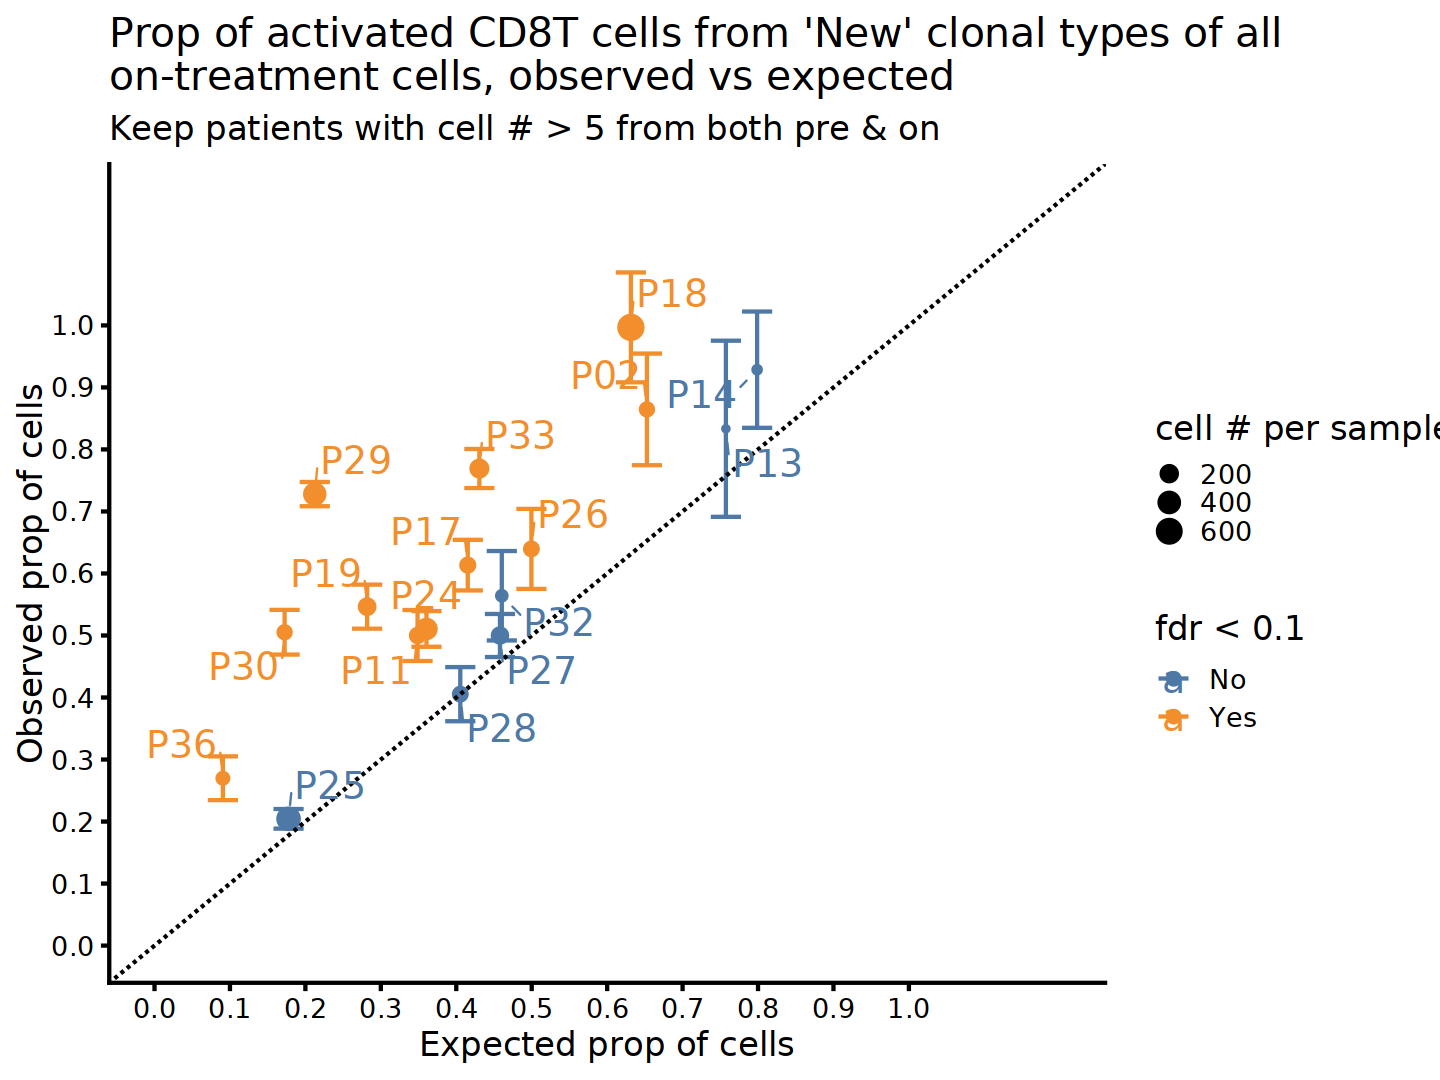

In [16]:
.cutoff <- 6
.title <- paste0(
    "Prop of ", "activated CD8T cells"," from 'New' clonal types of all ", "\n",
    "on-treatment cells, observed vs expected")
.subtitle <- paste0("Keep patients with cell # > ", 5, " from both pre & on")
fdr_cutoff <- 0.1


act_df <- cell_res_on[On >= .cutoff & Pre >= .cutoff] %>% 
    mutate(sig = if_else(padj_larger < fdr_cutoff, "Yes", "No")) %>% 
    mutate(prop_obs = S_obs/On, prop_exp = expected_S / On, sd_prop = sd_S / On)
p_act <- act_df %>% 
    ggplot(aes(x = prop_exp, y = prop_obs, color = sig)) +
        geom_errorbar(aes(ymin=prop_obs-sd_prop, ymax=prop_obs+sd_prop), width = 0.04) +
        geom_point(aes(size = On)) +
        geom_abline(intercept = 0, slope = 1, linetype="dashed") +
        geom_text_repel(aes(label=patientID), size = 8, max.overlaps = Inf, min.segment.length = 0, point.size= 8) +
        scale_color_tableau() +
        theme_classic(base_size=20) +
        scale_x_continuous(limits = c(0, 1.2), breaks = seq(0, 1, 0.1)) +
        scale_y_continuous(limits = c(0, 1.2), breaks = seq(0, 1, 0.1)) +
        labs(
            title = .title, subtitle=.subtitle, 
            x = "Expected prop of cells",
            y = "Observed prop of cells",
            color=paste0("fdr < ", fdr_cutoff), size="cell # per sample") +
        NULL
fig.size(9, 12)
p_act

# Other CD8T

## Overview

### Pre to On

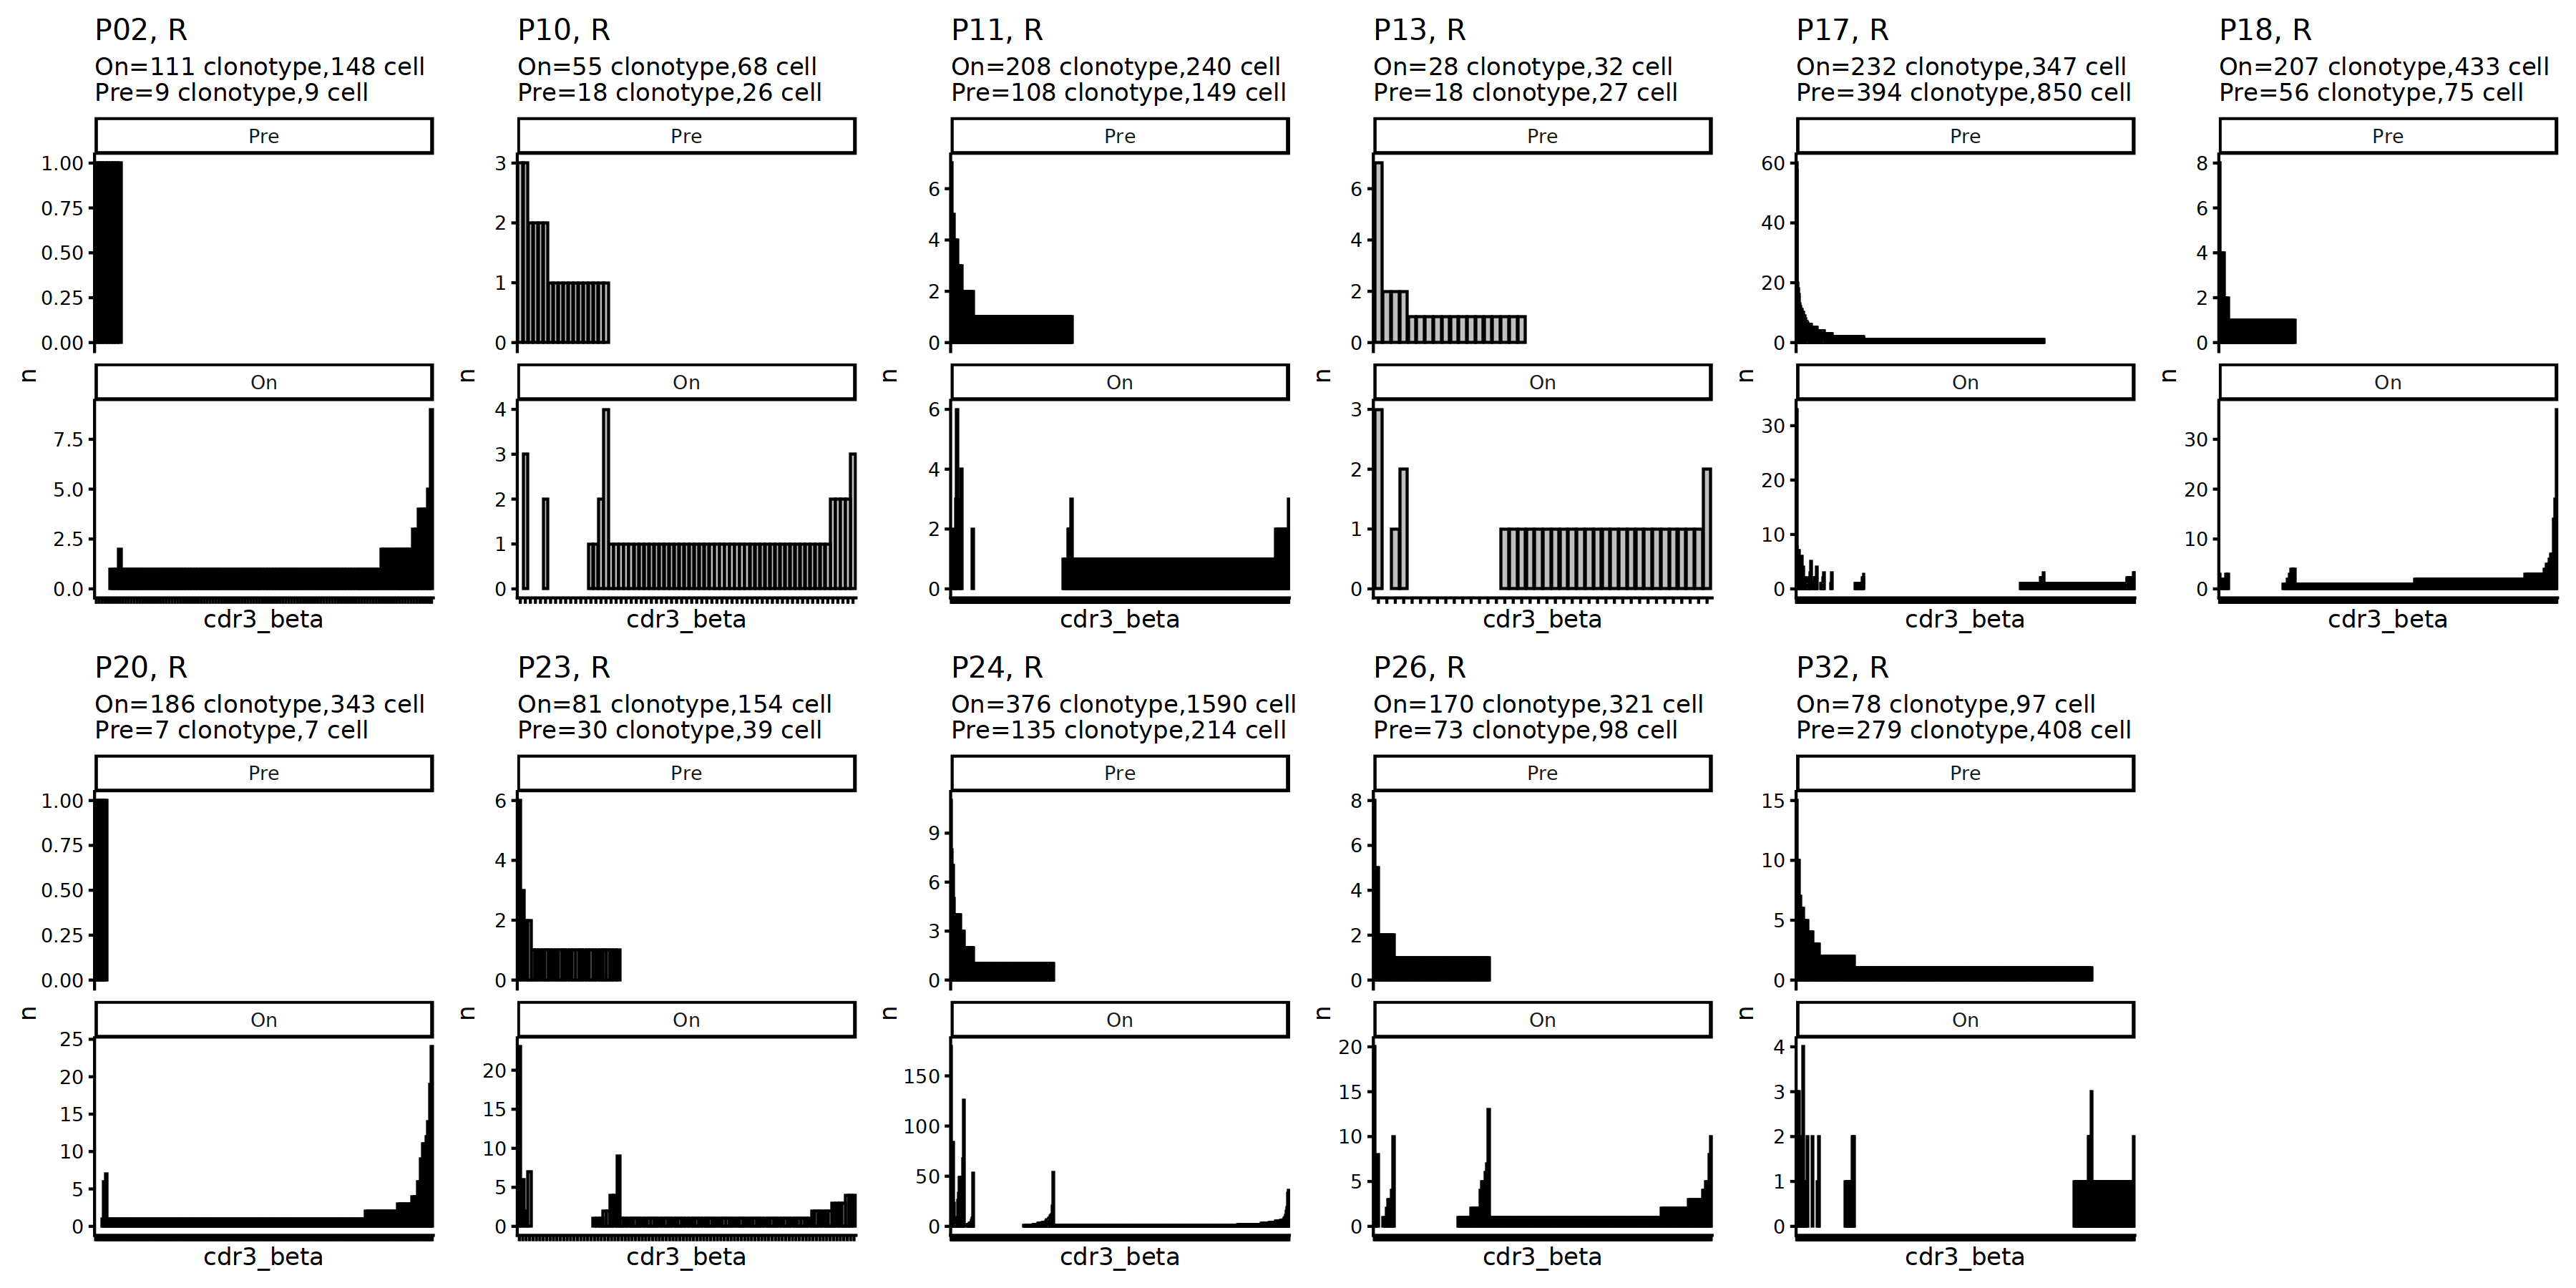

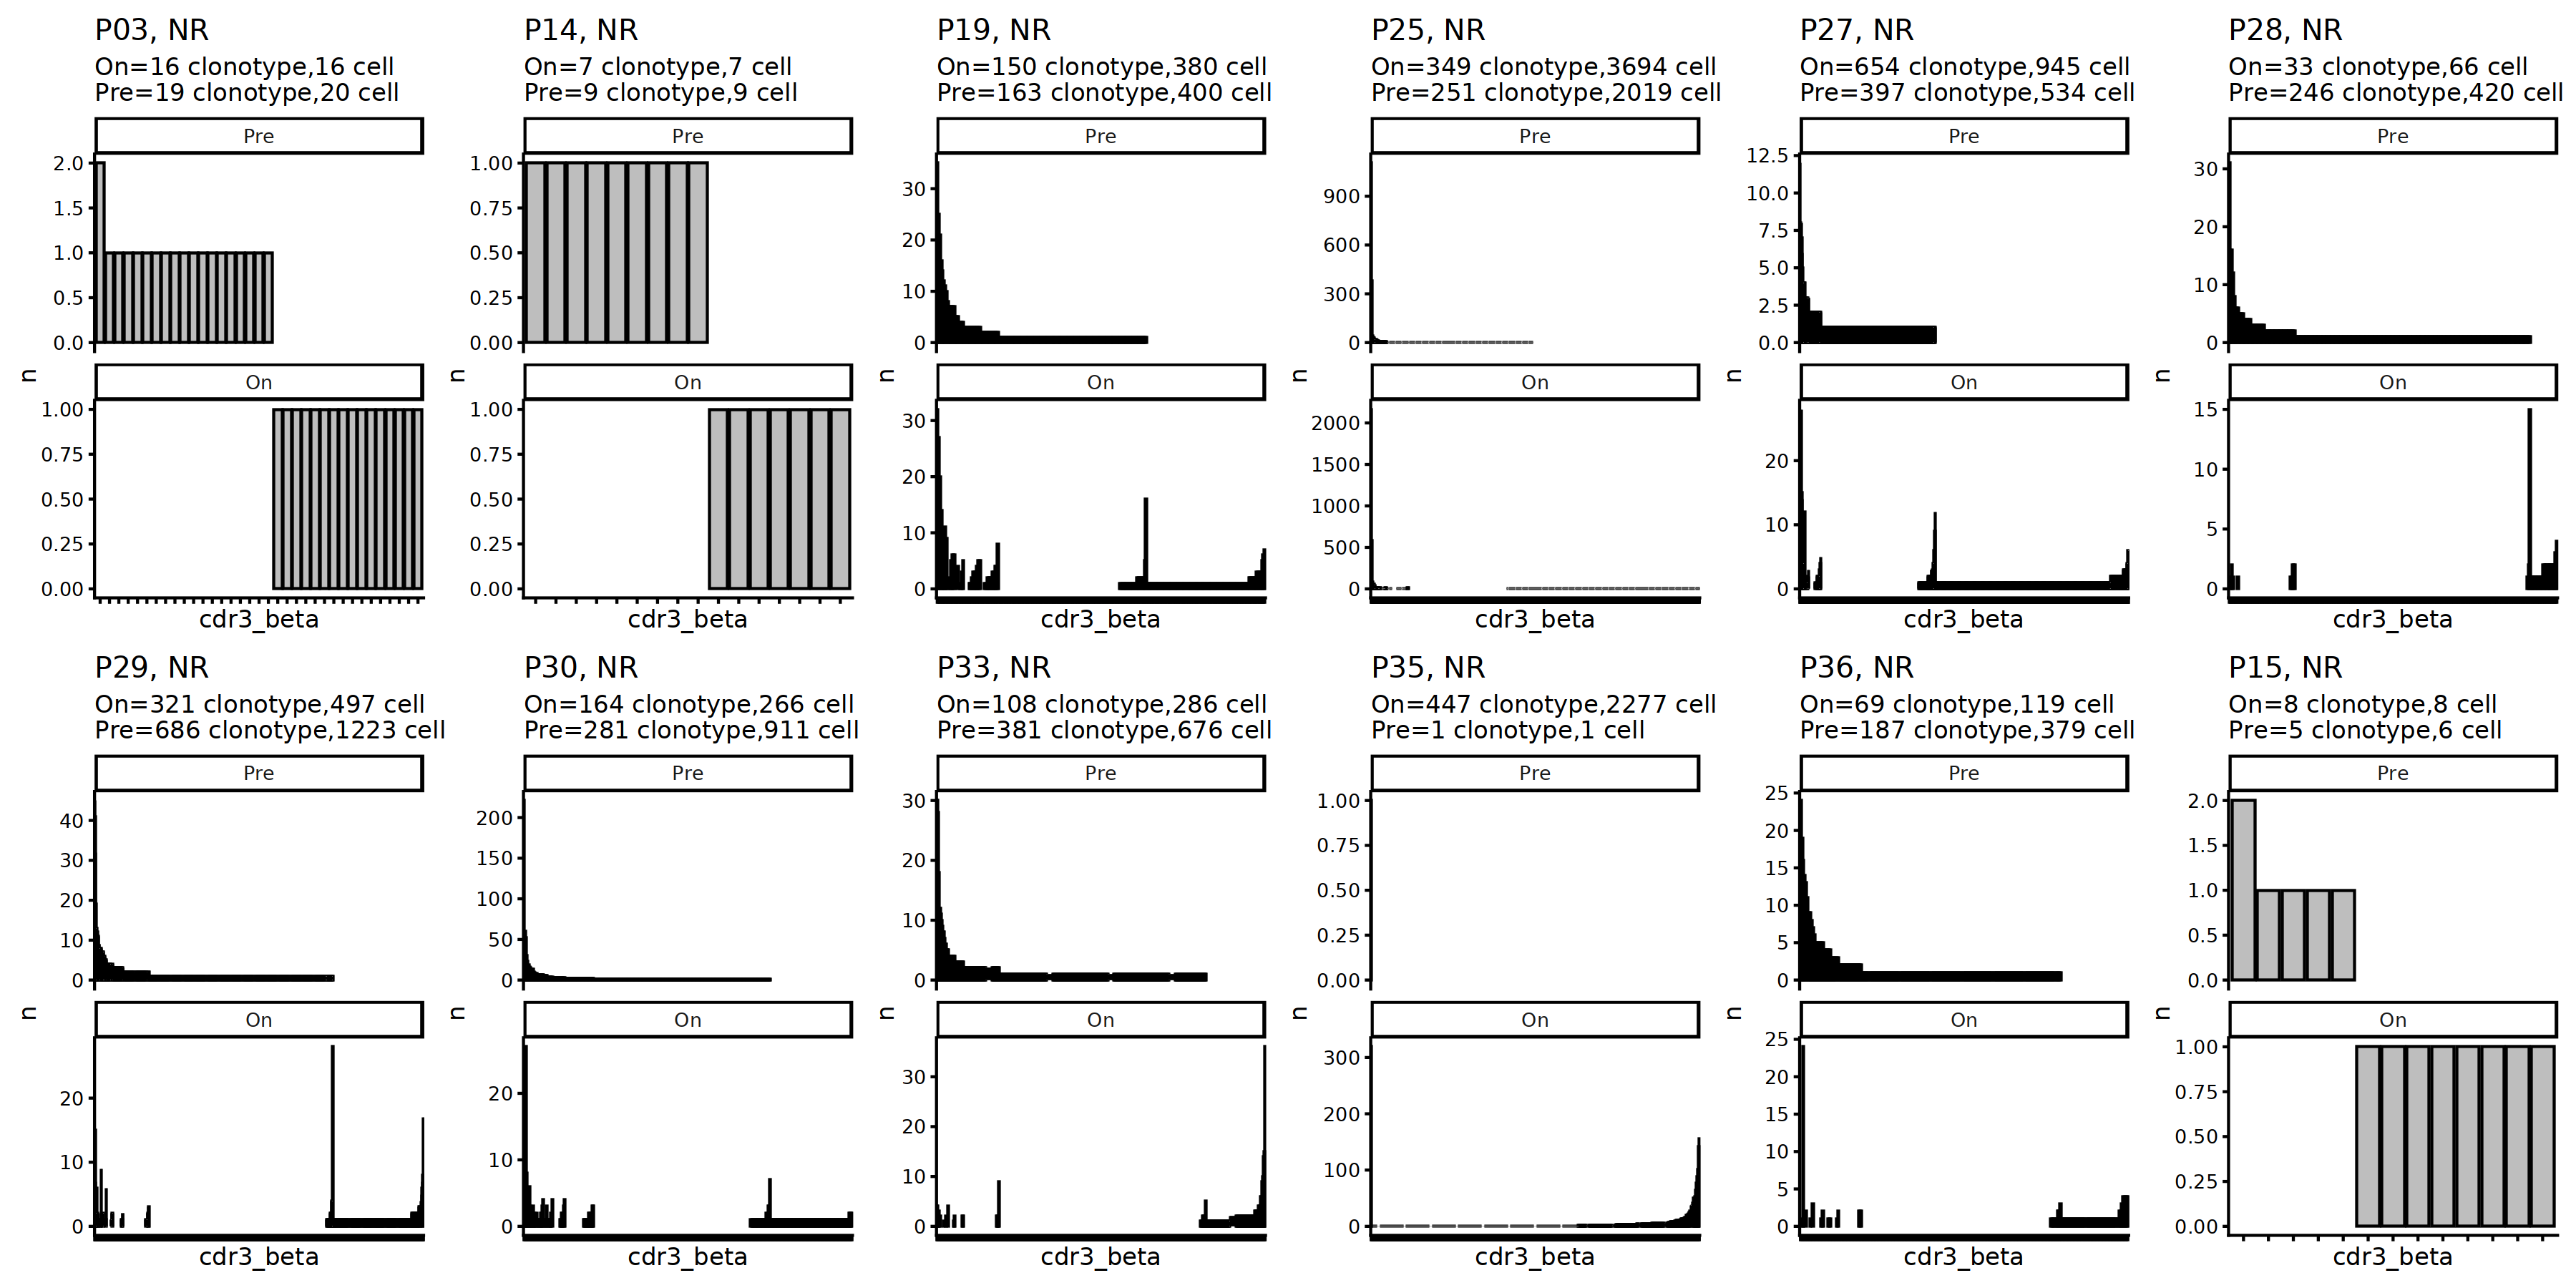

In [17]:
patientID_list <- nonact_cell %>% 
    dplyr::distinct(patientID, response) %>% 
    split(.$response) %>% 
    purrr::map(function(.df).df$patientID)

plist <- nonact_cell %>% 
    count(patientID, treatment, response, cdr3_beta) %>% 
    split(.$patientID) %>% 
    purrr::map(function(.df){
        if(length(unique(.df$treatment)) == 1) {
            cdr3_beta_lvl <- .df %>% arrange(desc(n)) %>% pull(cdr3_beta) 
        } else{
            cdr3_beta_lvl <- .df %>% 
                pivot_wider(names_from = "treatment", values_from = n, values_fill = 0) %>% 
                arrange(desc(Pre), On) %>% 
                pull(cdr3_beta)}
        
        patientID <- .df[1, "patientID"]
        response <- .df[1, "response"]
        num_df <- .df %>% 
            group_by(treatment) %>% 
            summarise(n_clonotype = n(), n_cell=sum(n)) %>%
            tibble::column_to_rownames("treatment")
        p <- .df %>% 
            mutate(cdr3_beta = factor(cdr3_beta, levels = cdr3_beta_lvl)) %>% 
            mutate(treatment = factor(treatment, levels=c("Pre", "On"))) %>% 
            ggplot(aes(x = cdr3_beta, y = n)) +
                geom_bar(stat = "identity", color = "black", fill = "gray") +
                facet_wrap(~ treatment, ncol=1, scales = "free_y") +
                theme_classic(base_size = 20) +
                theme(axis.text.x = element_blank()) +
                labs(title=paste0(patientID, ", ", response), subtitle=paste0(
                    "On=", num_df["On", "n_clonotype"], " clonotype", ",", 
                    num_df["On", "n_cell"], " cell", "\n",
                    "Pre=", num_df["Pre", "n_clonotype"], " clonotype", ",",
                    num_df["Pre", "n_cell"], " cell")) +
                NULL
    })

fig.size(15, 30)
plist[patientID_list$R] %>% 
    wrap_plots(ncol = 6)
plist[patientID_list$NR] %>% 
    wrap_plots(ncol = 6)

### On to Pre

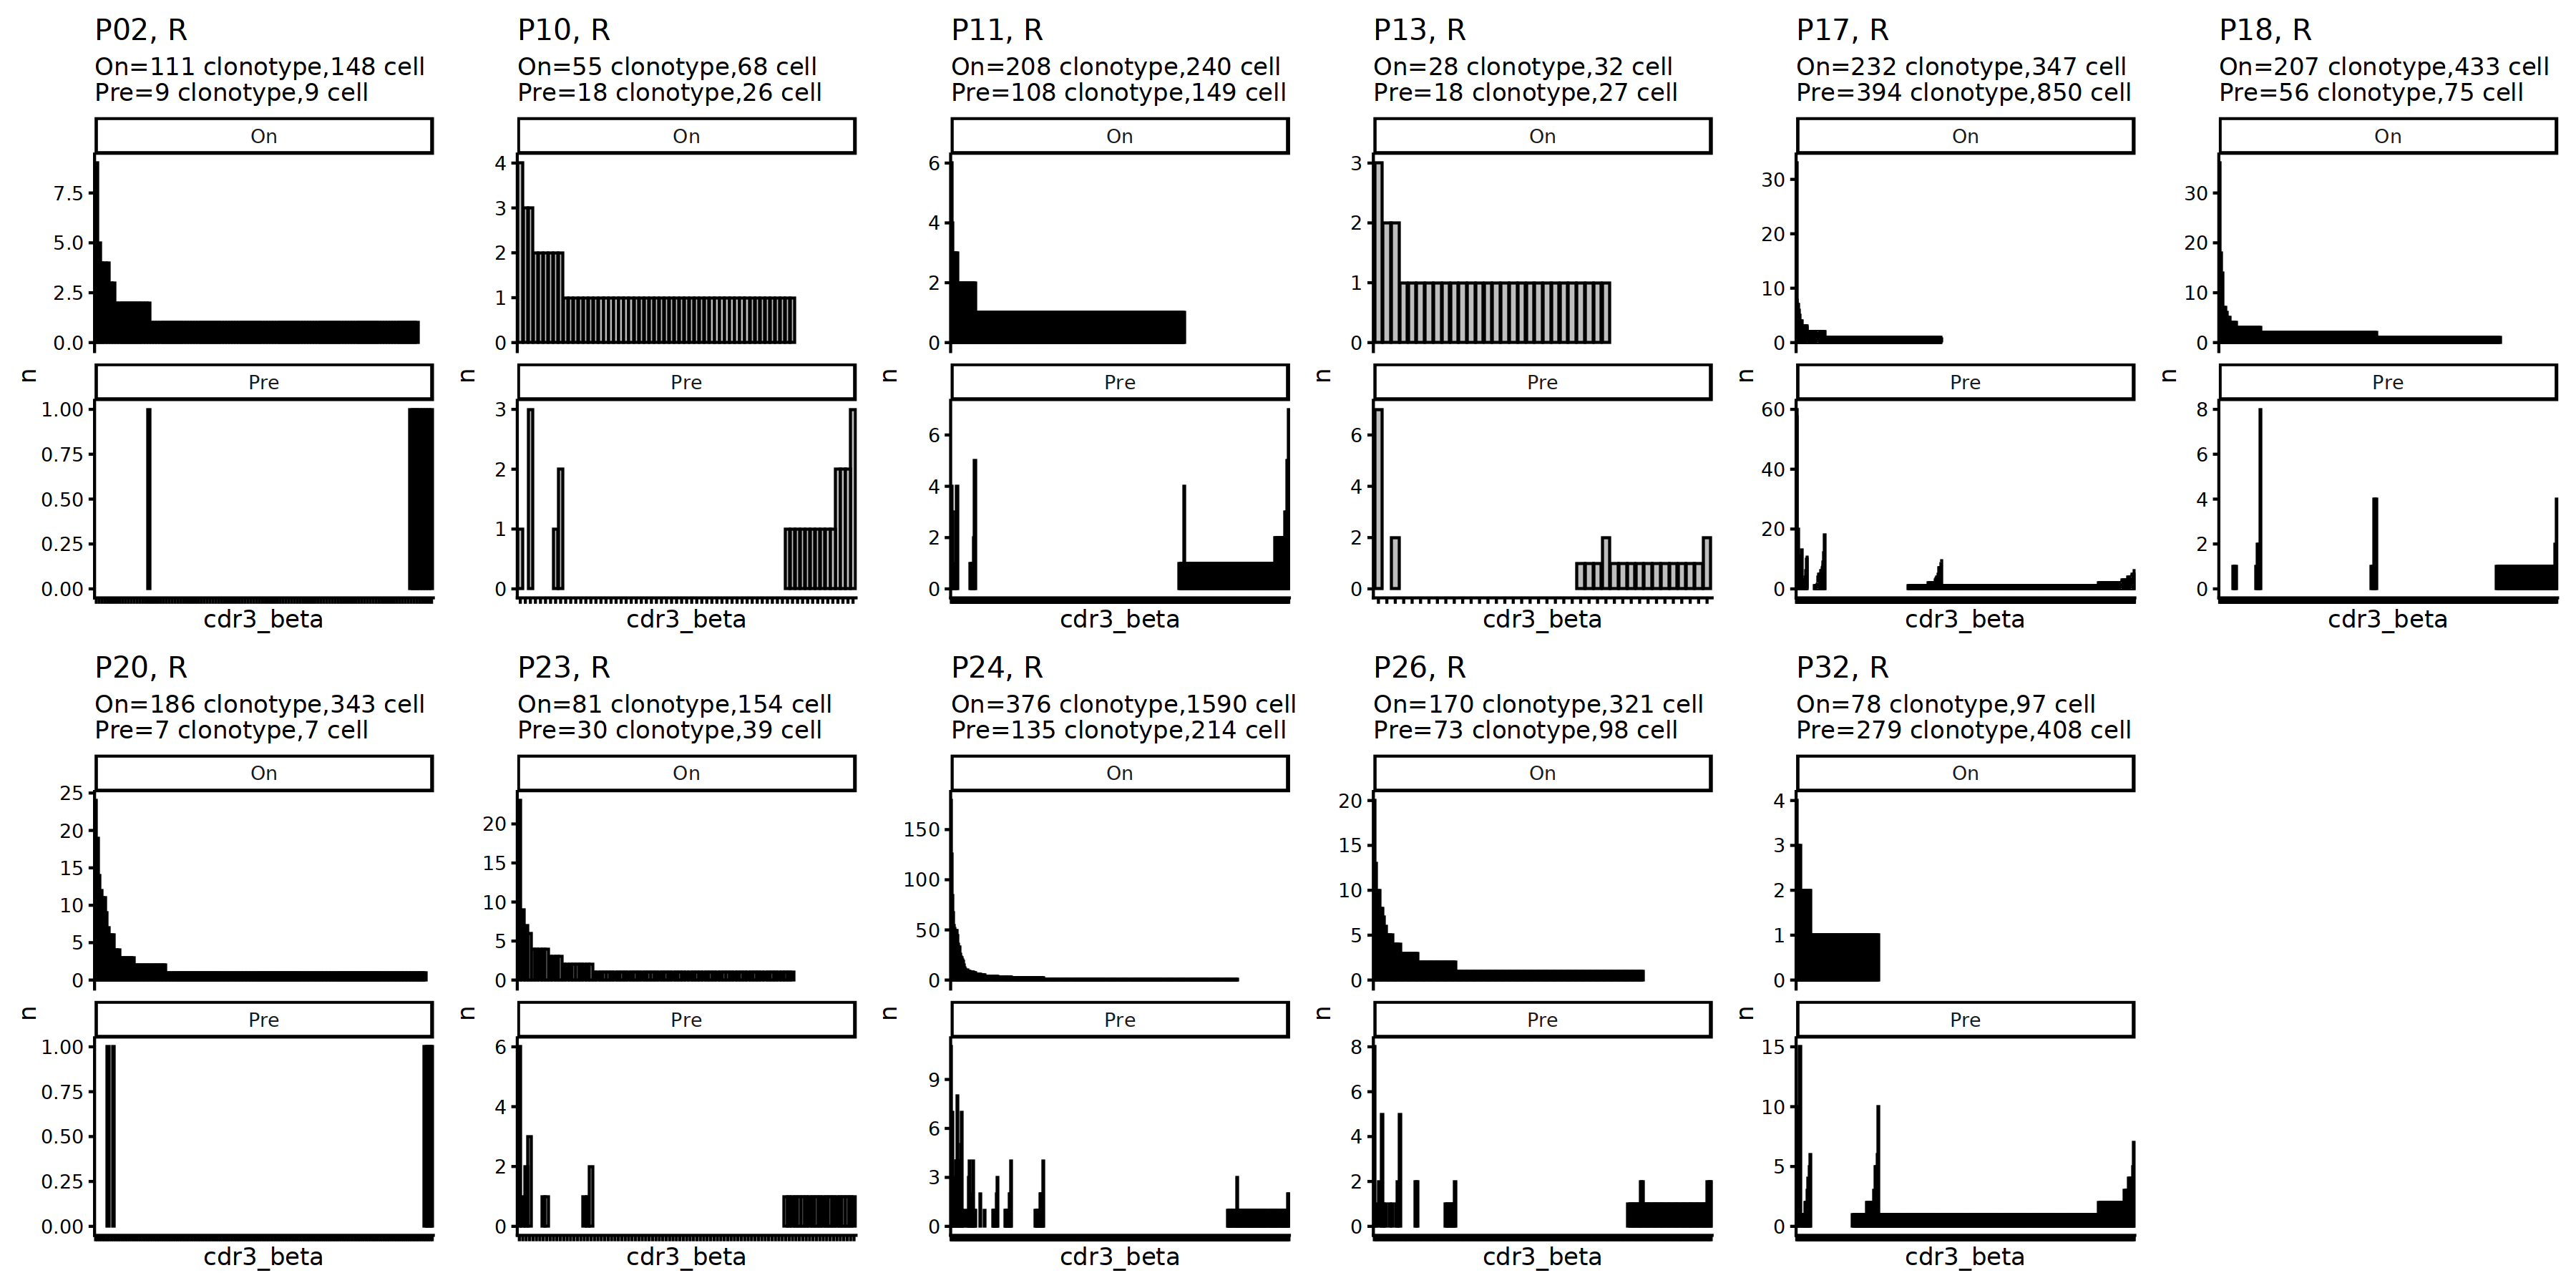

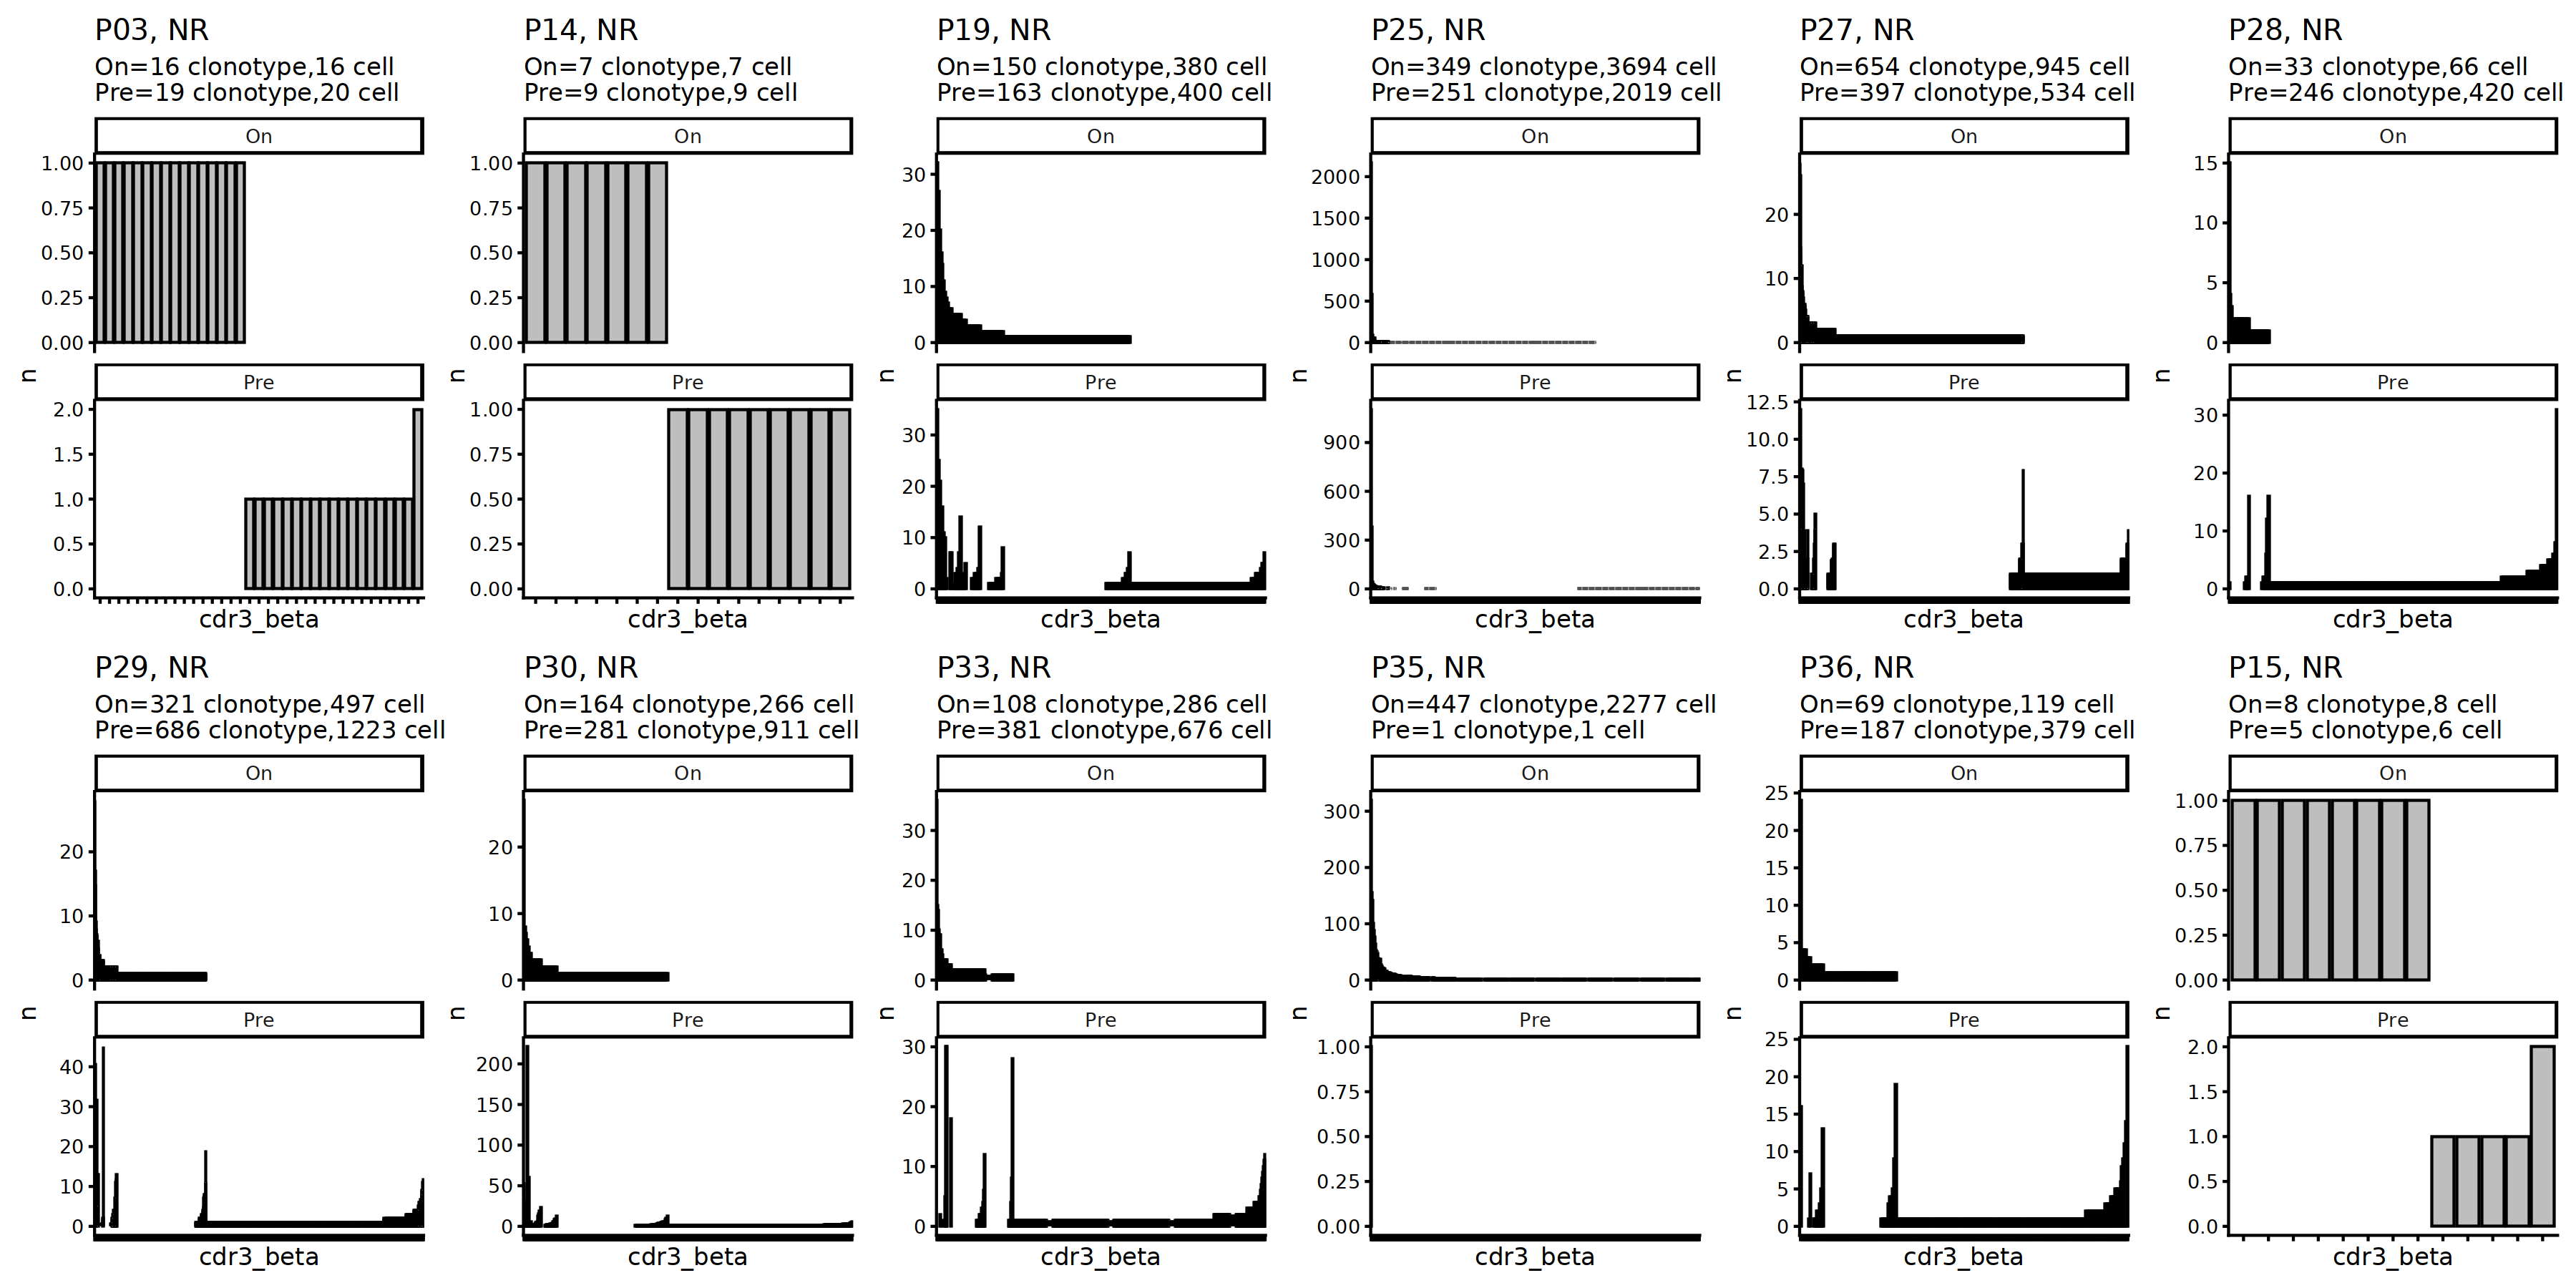

In [18]:
patientID_list <- nonact_cell %>% 
    dplyr::distinct(patientID, response) %>% 
    split(.$response) %>% 
    purrr::map(function(.df).df$patientID)

plist <- nonact_cell %>% 
    count(patientID, treatment, response, cdr3_beta) %>% 
    split(.$patientID) %>% 
    purrr::map(function(.df){
        if(length(unique(.df$treatment)) == 1) {
            cdr3_beta_lvl <- .df %>% 
                arrange(desc(n)) %>% 
                pull(cdr3_beta) 
        } else{
            cdr3_beta_lvl <- .df %>% 
                pivot_wider(names_from = "treatment", values_from = n, values_fill = 0) %>% 
                arrange(desc(On), Pre) %>% 
                pull(cdr3_beta) 
            
        }
        patientID <- .df[1, "patientID"]
        response <- .df[1, "response"]
        num_df <- .df %>% 
            group_by(treatment) %>% 
            summarise(n_clonotype = n(), n_cell=sum(n)) %>%
            tibble::column_to_rownames("treatment")
        .df %>% 
            mutate(cdr3_beta = factor(cdr3_beta, levels = cdr3_beta_lvl)) %>% 
            mutate(treatment = factor(treatment, levels=c("On", "Pre"))) %>% 
            ggplot(aes(x = cdr3_beta, y = n)) +
                geom_bar(stat = "identity", color = "black", fill = "gray") +
                facet_wrap(~ treatment, ncol=1, scales = "free_y") +
                theme_classic(base_size = 20) +
                theme(axis.text.x = element_blank()) +
                labs(title=paste0(patientID, ", ", response), subtitle=paste0(
                    "On=", num_df["On", "n_clonotype"], " clonotype", ",", 
                    num_df["On", "n_cell"], " cell", "\n",
                    "Pre=", num_df["Pre", "n_clonotype"], " clonotype", ",",
                    num_df["Pre", "n_cell"], " cell")) +
                NULL
    })

fig.size(15, 30)
plist[patientID_list$R] %>% 
    wrap_plots(ncol = 6)
plist[patientID_list$NR] %>% 
    wrap_plots(ncol = 6)

### Num of cells per sample

In [19]:
nonact_cell %>% 
    count(patientID, treatment) %>% 
    pivot_wider(values_from = "n", names_from = "treatment", values_fill=0)

nonact_cell %>% 
    unique() %>% 
    count(patientID, treatment) %>% 
    pivot_wider(values_from = "n", names_from = "treatment", values_fill=0)

patientID,On,Pre
<chr>,<int>,<int>
P02,148,9
P03,16,20
P10,68,26
P11,240,149
P13,32,27
P14,7,9
P15,8,6
P17,347,850
P18,433,75


patientID,On,Pre
<chr>,<int>,<int>
P02,133,9
P03,16,20
P10,66,20
P11,225,130
P13,29,24
P14,7,9
P15,8,6
P17,279,540
P18,255,65


## Test num of cell

In [20]:
system.time({
plan(multicore)
nonact_cell_res_on = permute_cell_all(nonact_cell, 'On')
nonact_cell_res_pre = permute_cell_all(nonact_cell, 'Pre')
    
})

Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.

    user   system  elapsed 
3177.003   11.714  557.983 

In [21]:
.cutoff = 6
list(On = nonact_cell_res_on[On >= .cutoff & Pre >= .cutoff],
     Pre = nonact_cell_res_pre[On >= .cutoff & Pre >= .cutoff]) %>% 
    bind_rows(.id = "type") %>% 
    as.data.frame() %>% 
    split(~type) %>% 
    purrr::map(function(.df)split(.df, .df$padj_larger < 0.1))

,type,patientID,S_obs,p_larger,p_smaller,expected_S,sd_S,response,On,Pre,padj_larger,padj_smaller
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>
10,On,P26,205,0.05753,0.95262,188.97580,9.5583434,R,321,98,0.1248482,1.00000
11,On,P27,642,0.05971,0.94901,622.15607,12.3042540,NR,945,534,0.1248482,1.00000
12,On,P20,329,0.14561,0.87058,311.93927,14.7617276,R,343,7,0.2576177,1.00000
13,On,P24,563,0.14368,0.86429,535.43639,25.4804938,R,1590,214,0.2576177,1.00000
14,On,P25,337,0.22053,0.79697,324.46395,15.9275609,NR,3694,2019,0.3622993,1.00000
15,On,P13,23,0.25093,0.86800,21.03634,2.2088703,R,32,27,0.3847593,1.00000
16,On,P02,143,0.29376,0.78491,139.38499,4.5055849,R,148,9,0.4222800,1.00000
17,On,P10,55,0.33393,0.76532,53.17368,3.2445771,R,68,26,0.4517876,1.00000
18,On,P03,16,0.49152,1.00000,15.49152,0.4999306,NR,16,20,0.5949979,1.00000


## Plot

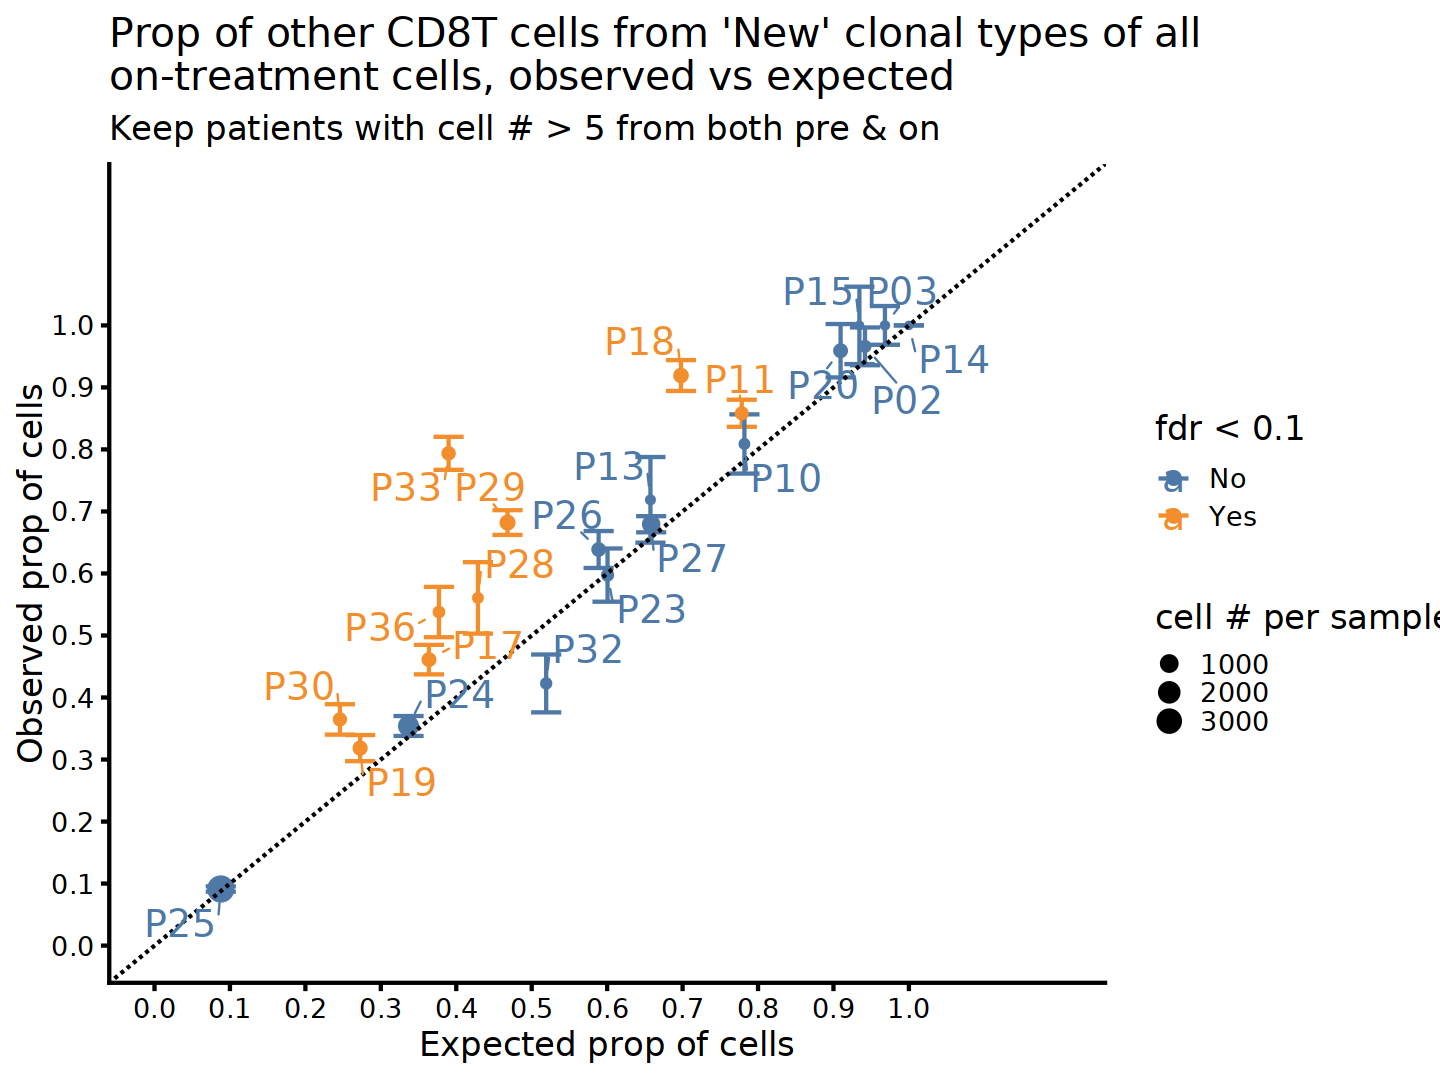

In [22]:
.cutoff <- 6
.title <- paste0(
    "Prop of ", "other CD8T cells"," from 'New' clonal types of all ", "\n",
    "on-treatment cells, observed vs expected")
.subtitle <- paste0("Keep patients with cell # > ", 5, " from both pre & on")
fdr_cutoff <- 0.1


other_df <- nonact_cell_res_on[On >= .cutoff & Pre >= .cutoff] %>% 
    mutate(sig = if_else(padj_larger < fdr_cutoff, "Yes", "No")) %>% 
    mutate(prop_obs = S_obs/On, prop_exp = expected_S / On, sd_prop = sd_S / On)
p_other <- other_df %>% 
    ggplot(aes(x = prop_exp, y = prop_obs, color = sig)) +
        geom_errorbar(aes(ymin=prop_obs-sd_prop, ymax=prop_obs+sd_prop), width = 0.04) +
        geom_point(aes(size = On)) +
        geom_abline(intercept = 0, slope = 1, linetype="dashed") +
        geom_text_repel(aes(label=patientID), size = 8, max.overlaps = Inf, min.segment.length = 0, point.size= 8) +
        scale_color_tableau() +
        theme_classic(base_size=20) +
        scale_x_continuous(limits = c(0, 1.2), breaks = seq(0, 1, 0.1)) +
        scale_y_continuous(limits = c(0, 1.2), breaks = seq(0, 1, 0.1)) +
        labs(
            title = .title, subtitle=.subtitle, 
            x = "Expected prop of cells",
            y = "Observed prop of cells",
            color=paste0("fdr < ", fdr_cutoff), size="cell # per sample") +
        NULL
fig.size(9, 12)
p_other

# act vs non-act

[[1]]

	Wilcoxon signed rank exact test

data:  pull(df, "non-activated CD8T") and pull(df, "Activated CD8T")
V = 17, p-value = 0.003159
alternative hypothesis: true location shift is not equal to 0



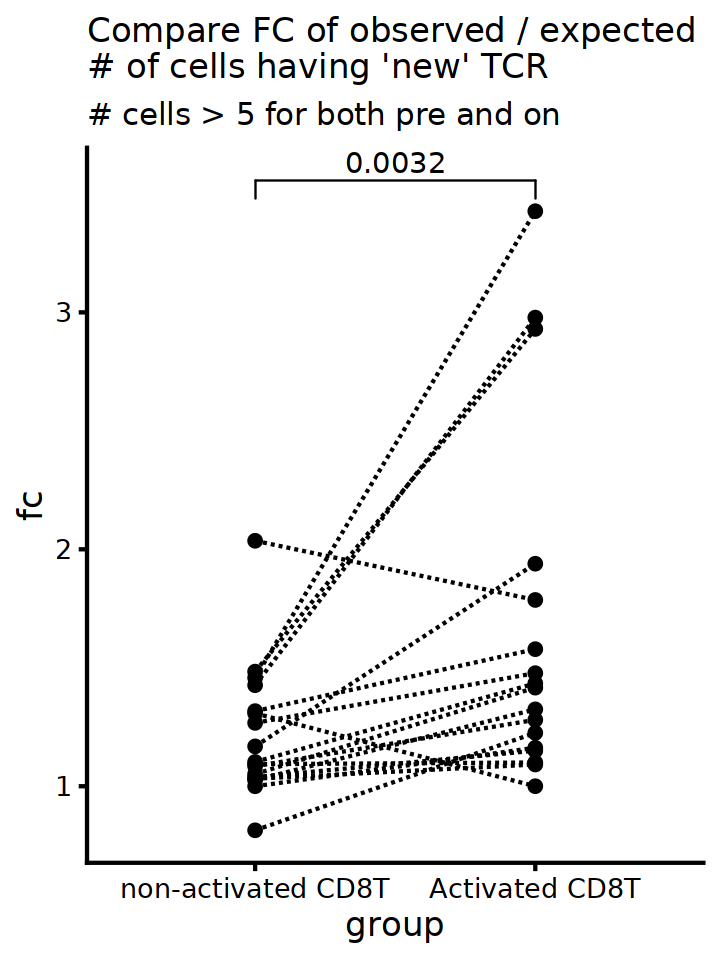

In [23]:
.cutoff <- 6

act_other_res_on <- full_join(cell_res_on, nonact_cell_res_on, by=c("patientID", "response"), suffix = c("_act", "_other")) %>% 
    mutate(fc_act = S_obs_act / expected_S_act, fc_other=S_obs_other/expected_S_other) 

act_other_df <- act_other_res_on %>% 
    filter(!is.na(fc_act)) %>% 
    # Keep patients with > cutoff cells
    filter(On_act>=.cutoff & Pre_act>=.cutoff & On_other>=.cutoff & Pre_other>=.cutoff) %>% 
    pivot_longer(cols = fc_act:fc_other, values_to = "fc", names_to = "group") %>% 
    mutate(group = if_else(group == "fc_other", "non-activated CD8T", "Activated CD8T")) %>% 
    mutate(group = factor(group, levels = c("non-activated CD8T", "Activated CD8T"))) %>% 
    arrange(patientID, group) 

p_act_other <- act_other_df %>% 
    ggplot(aes(x=group, y=fc, group=patientID)) +
        geom_line(linetype="dashed") +
        geom_point() +
        geom_signif(
            comparisons = list(c("non-activated CD8T", "Activated CD8T")),
            test = "wilcox.test", test.args = list(paired=TRUE), textsize=6) +
        labs(
            title = paste0(
                "Compare FC of observed / expected", "\n",  "# of cells having 'new' TCR"),
            subtitle = "# cells > 5 for both pre and on") +
        theme_classic(base_size=20) +
        theme(plot.title = element_text(size = 20), plot.subtitle = element_text(size=18)) +
        NULL
fig.size(8, 6)
p_act_other

act_other_df %>% 
    pivot_wider(names_from = group, values_from = fc) %>% 
    list()  %>% 
    purrr::map(function(df){
        wilcox.test(pull(df, "non-activated CD8T"), pull(df, "Activated CD8T"), paired = TRUE)
    })

In [24]:
sessionInfo()

R version 4.1.2 (2021-11-01)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 9.7 (Plow)

Matrix products: default
BLAS/LAPACK: /home/hoy821/miniforge3/lib/libopenblasp-r0.3.24.so

Random number generation:
 RNG:     L'Ecuyer-CMRG 
 Normal:  Inversion 
 Sample:  Rejection 
 
locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] patchwork_1.3.2   ggpubr_0.6.0      ggthemes_4.2.4    ggrepel_0.9.4    
 [5] furrr_0.3.1       future_1.69.0     ggplot2_4.0.1     tidyr_1.3.0      
 [9] dplyr_1.1.2       data.table_1.18.0

loaded v